# Cross-Cohort Niche Label Transfer: H&E-Supervised Spatial Tissue Analysis

## Abstract

Spatial transcriptomics (e.g., Xenium) provides rich biological context but is cost-prohibitive at scale.
H&E staining is universally available. This notebook demonstrates a four-step pipeline that uses
Xenium data only during label construction, then trains a model that predicts biologically meaningful
niche types from H&E-derived cell-neighbor composition features alone.

The cohort consists of 4 biological samples (S1–S4), each sectioned at three tissue levels
(Top / Mid / Bot), yielding **12 tissue pieces** labeled P1–P12. Two independent groups are formed:

- **Group 1 (G1)**: P1–P6 (samples S1, S2)
- **Group 2 (G2)**: P7–P12 (samples S3, S4)

WSInsight niche discovery is run **independently** on each group, so niche IDs are not shared across groups.

## Core Scientific Contribution

1. **Independent niche discovery** per cohort group prevents label leakage between groups.
2. **Within-group label consistency** (G1A vs G1B): Marker-based labeling (DE → hypergeometric test)
   is run independently on two halves of G1 that share the same niche ID space. Agreement confirms
   that cell-neighbor composition reliably encodes biological niche identity.
3. **Cross-group label transfer** (G1 → G2): A neural network trained on G1 H&E features predicts
   niche types on G2. G2's independently derived empirical-p labels serve as held-out ground truth.

## Problem Statement

Let $\phi_i \in \mathbb{R}^{2d}$ be the neighbor-composition feature vector for niche group $i$
(mean and standard deviation of $d$ H&E-derived features over all member cells):
$$
\phi_i = [\mu_{i,1}, \dots, \mu_{i,d},\ \sigma_{i,1}, \dots, \sigma_{i,d}]
$$

Learn a function $f_\theta(\phi_i) \rightarrow y_i$ where $y_i$ is a human-readable niche type
(e.g., *tumor proliferative*, *immune interferon*, *TLS lymphoid*).

At inference time, Xenium is **not required**.

---

## Pipeline Overview

| Step | Input | Method | Output | Validation |
|------|-------|--------|--------|------------|
| 0 | P1–P12 H&E | WSInsight (2 independent runs) | G1 niche IDs, G2 niche IDs | — |
| 1 (G1A) | G1A Xenium (P1–P3) | DE → hypergeometric marker-p | G1 niche labels | — |
| 2 (G1B) | G1B Xenium (P4–P6) | Independent DE → marker-p | G1B niche labels | CM vs G1A labels |
| 3 | G1 H&E features + labels | Neural network (MLP) | Trained classifier | G1B internal validation |
| 4 | G2 H&E features | Trained NN (no Xenium) | Predicted G2 labels | G2 Xenium empirical-p labels |

## Stage 0 · Setup

### 0-A: Install Dependencies

Install all required Python packages. Run once per new environment; safe to re-run (pip is idempotent).

In [1]:
# Install required packages for the notebook.
# Use the current kernel's pip so they land in the same environment as this notebook.
%pip install -q --disable-pip-version-check pandas matplotlib seaborn scanpy scikit-learn torch tqdm scipy

import importlib

required_packages = [
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scanpy", "scanpy"),
    ("scikit-learn", "sklearn"),
    ("torch", "torch"),
    ("tqdm", "tqdm"),
    ("scipy", "scipy"),
]

missing = []
for _, module_name in required_packages:
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(module_name)

if missing:
    raise RuntimeError(f"Missing packages after install: {missing}")

print("All required packages are available.")


pip_system_certs: ERROR: could not register module: No module named 'wrapt'
Note: you may need to restart the kernel to use updated packages.
All required packages are available.


### 0-B: Imports

Load all standard libraries used throughout the notebook.

In [2]:
# Standard and scientific imports used throughout every stage.
import os
import re
import ast
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import hypergeom
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_curve, auc,
)

# Scanpy display settings: less verbose, clean figures.
sc.settings.verbosity = 1
sc.set_figure_params(dpi=110, frameon=False)

print("All imports successful.")


All imports successful.


/opt/anaconda3/envs/spie2027/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0-C: Configuration

All paths, sample names, and hyperparameters live here. **Edit only this cell** when adapting to a new dataset.

Sample assignment:
```
G1A  P1-P3  S1_Top, S1_Mid, S1_Bot
G1B  P4-P6  S2_Top, S2_Mid, S2_Bot
G2   P7-P12 S3_Top, S3_Mid, S3_Bot, S4_Top, S4_Mid, S4_Bot
```

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# SAMPLE DEFINITIONS
# Adjust only the strings below when working with a different cohort.
# ──────────────────────────────────────────────────────────────────────────────

# G1A: first half of Group 1 (used to build niche labels via marker signatures)
G1A_STEMS = [
    "Human_Breast_Biomarkers_S1_Top_he_image.ome",
    "Human_Breast_Biomarkers_S1_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S1_Bot_he_image.ome",
]

# G1B: second half of Group 1 (independent marker-based label consistency check)
G1B_STEMS = [
    "Human_Breast_Biomarkers_S2_Top_he_image.ome",
    "Human_Breast_Biomarkers_S2_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S2_Bot_he_image.ome",
]

# G2: second independent group (cross-cohort transfer target)
G2_STEMS = [
    "Human_Breast_Biomarkers_S3_Top_he_image.ome",
    "Human_Breast_Biomarkers_S3_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S3_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S4_Top_he_image.ome",
    "Human_Breast_Biomarkers_S4_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S4_Bot_he_image.ome",
]

# Derived convenience lists.
G1_STEMS  = G1A_STEMS + G1B_STEMS   # all Group 1 samples
ALL_STEMS = G1_STEMS + G2_STEMS     # full cohort

# ──────────────────────────────────────────────────────────────────────────────
# PATHS
# ──────────────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("/workspace/spie2027")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUTS_VERSION     = "v1"   # change when re-running with new wsinsight outputs
OUTPUTS_ROOT        = PROJECT_ROOT / "outputs" / OUTPUTS_VERSION
IMPORTED_XENIUM_DIR = OUTPUTS_ROOT / "imported-xenium"

# ──────────────────────────────────────────────────────────────────────────────
# CENTRAL CONFIG DICT  (carry-forward variable used by all downstream cells)
# ──────────────────────────────────────────────────────────────────────────────
CFG = {
    # ── Primary analysis inputs (required) ───────────────────────────────────
    "niche_marker_csv":   PROJECT_ROOT / "nichemarkers-v1.csv",
    "imported_xenium_dir": IMPORTED_XENIUM_DIR,

    # ── WSInsight re-run inputs (only needed when RUN_WSINSIGHT = True) ───────
    "image_list_txt":     PROJECT_ROOT / "data" / "imglist.txt",
    "sptx_map_tsv":       PROJECT_ROOT / "data" / "sptxlist.txt",
    "run_script":         PROJECT_ROOT / "run-wsinsight-all.sh",

    # ── Output roots ─────────────────────────────────────────────────────────
    "outputs_version":    OUTPUTS_VERSION,
    "outputs_root":       OUTPUTS_ROOT,

    # ── Sub-output directories (one per stage) ────────────────────────────────
    "outdir_g1a":         OUTPUTS_ROOT / "g1a_markers",
    "outdir_g1b":         OUTPUTS_ROOT / "g1b_markers",
    "outdir_g2":          OUTPUTS_ROOT / "g2_markers",
    "nn_dir":             OUTPUTS_ROOT / "nn",

    # ── Sample lists ─────────────────────────────────────────────────────────
    "g1a_stems":          G1A_STEMS,
    "g1b_stems":          G1B_STEMS,
    "g1_stems":           G1_STEMS,
    "g2_stems":           G2_STEMS,
    "all_stems":          ALL_STEMS,

    # ── Reproducibility seed ──────────────────────────────────────────────────
    "seed": 42,

    # ── Neural network hyperparameters (adjust freely) ────────────────────────
    "nn_epochs":          50,
    "nn_batch_size":      64,
    "nn_lr":              1e-3,
    "nn_weight_decay":    1e-4,
    "nn_hidden":          [256, 128],   # hidden layer sizes
    "nn_dropout":         0.3,

    # ── Training-set augmentation via within-niche sampling ───────────────────
    "nn_use_sampling_augmentation": True,
    "nn_aug_repeats":     3,            # augmented vectors per (sample, niche) base row
    "nn_aug_sample_frac": 0.70,         # fraction of niche cells sampled per augmented row
    "nn_aug_min_cells":   12,           # require at least this many cells to augment a niche row
    "nn_aug_replace":     True,         # bootstrap-like sampling with replacement

    # ── DE thresholds (marker extraction) ────────────────────────────────────
    "de_min_cells":       20,
    "de_pval":            0.001,
    "de_logfc":           0.5,
    "de_pval_relaxed":    0.01,
    "de_logfc_relaxed":   0.25,
    "de_min_markers":     15,

    # ── Empirical-p label assignment ──────────────────────────────────────────
    "empirical_p_fdr_threshold": 0.05,
    "marker_label_min_overlap":  1,
}

# ── Preflight checks: only what's required for analysis ──────────────────────
# (WSInsight manifests / run script are checked separately in Stage 0-D.)
_required = {
    "niche_marker_csv":   CFG["niche_marker_csv"],
    "imported_xenium_dir": CFG["imported_xenium_dir"],
}
_missing = [f"  {k}: {v}" for k, v in _required.items() if not Path(v).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing required inputs (WSInsight must have been run first):\n" +
        "\n".join(_missing)
    )

# Create all output directories now so later saves never fail.
for _key in ["outdir_g1a", "outdir_g1b", "outdir_g2", "nn_dir"]:
    CFG[_key].mkdir(parents=True, exist_ok=True)

# Set global random seeds for reproducibility.
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

# Human-readable summary.
print("Configuration loaded.")
print(f"  Outputs version  : {CFG['outputs_version']}")
print(f"  imported-xenium  : {CFG['imported_xenium_dir']}")
print(f"  Marker catalog   : {CFG['niche_marker_csv']}")
print(f"  All samples      : {len(ALL_STEMS)}  "
      f"(G1A={len(G1A_STEMS)}, G1B={len(G1B_STEMS)}, G2={len(G2_STEMS)})")
print("Sampling augmentation:")
print(f"  enabled={CFG['nn_use_sampling_augmentation']}  "
      f"repeats={CFG['nn_aug_repeats']}  frac={CFG['nn_aug_sample_frac']}  "
      f"replace={CFG['nn_aug_replace']}")
print(f"Empirical-p FDR threshold: {CFG['empirical_p_fdr_threshold']}")


Configuration loaded.
  Outputs version  : v1
  imported-xenium  : /workspace/spie2027/outputs/v1/imported-xenium
  Marker catalog   : /workspace/spie2027/nichemarkers-v1.csv
  All samples      : 12  (G1A=3, G1B=3, G2=6)
Sampling augmentation:
  enabled=True  repeats=3  frac=0.7  replace=True
Empirical-p FDR threshold: 0.05


---

## Stage 0-D · WSInsight Pipeline

### Background (beginner)

**Why two independent runs?**
If G1 and G2 were clustered together, their niche IDs would be entangled. Running independently
ensures that a niche ID in G2 is defined purely from G2's own data. Later, the NN learns to map
H&E neighbor compositions (not niche IDs) to biology, enabling true cross-cohort transfer.

**What each command does:**
1. `wsinsight run` — detects cells and extracts H&E features per cell.
2. `wsinsight niche` — builds a kNN graph, learns graph embeddings (DGI), then clusters into niches.
3. `wsinsight import --include niche` — maps Xenium expression onto H&E cells for supervised labeling.

---

### Math 1 · k-Nearest Neighbors (kNN) Graph

For each cell $i$ with feature vector $x_i \in \mathbb{R}^d$, compute pairwise Euclidean distance:
$$
d(x_i, x_j) = \|x_i - x_j\|_2 = \sqrt{\sum_{m=1}^{d}(x_{im} - x_{jm})^2}
$$
Connect cell $i$ to its $k$ nearest cells. The graph adjacency matrix $A \in \{0,1\}^{n \times n}$ is:
$$
A_{ij} = 1 \;\text{if}\; j \in \text{kNN}(i), \quad A_{ij} = 0 \;\text{otherwise}
$$

---

### Math 2 · Deep Graph Infomax (DGI)

DGI learns cell embeddings $h_i \in \mathbb{R}^{d'}$ by maximising mutual information between
local (cell) representations and a global graph summary $s$:
$$
\mathcal{L}_{\text{DGI}}
= \mathbb{E}\!\left[\tfrac{1}{n}\sum_{i} \log D(h_i, s)\right]
+ \mathbb{E}\!\left[\tfrac{1}{n}\sum_{i} \log\!\left(1 - D(\tilde{h}_i, s)\right)\right]
$$
where $D(\cdot,\cdot)$ discriminates real cell–graph pairs from corrupted (shuffled) ones
$\tilde{h}_i$. The learned $h_i$ captures meaningful neighbourhood structure while suppressing noise.

---

### Math 3 · Leiden Clustering (community detection)

Leiden optimises a quality function (modularity $Q$) over the graph partition $\mathcal{P}$:
$$
Q(\mathcal{P}) = \frac{1}{2m}\sum_{c \in \mathcal{P}}
\!\left[e_c - \gamma \frac{K_c^2}{2m}\right]
$$
where $m$ = total edge weight, $e_c$ = internal edge weight of community $c$,
$K_c$ = sum of degrees in $c$, $\gamma$ = resolution parameter.
Higher $Q$ means more edges within communities than expected by chance.

---

### Math 4 · KMeans (centroid clustering)

For $K$ clusters with centroids $\{\mu_k\}$, KMeans minimises total within-cluster variance:
$$
\min_{\{\mu_k\}} \sum_{i=1}^{n} \min_{k} \|x_i - \mu_k\|_2^2
$$
Solved by alternating assignment and centroid update steps.
$x_i$ here is the DGI-learned embedding for cell $i$.

In [4]:
# Stage 0-D: WSInsight pipeline execution.
#
# This stage is INFORMATIONAL by default (RUN_WSINSIGHT = False).
# It prints the commands that were used to generate the .h5ad files.
# Set RUN_WSINSIGHT = True only if you need to regenerate the data from scratch.
RUN_WSINSIGHT = False

commands = [
    f"./wsinsight-docker-run.sh . \"\" wsinsight run -i image-list:///{CFG['image_list_txt']} -o {CFG['outputs_root']} -b 32 -n 1 -z /app/zoo/huangch/CellViT-SAM-H-x40/main/",
    f"./wsinsight-docker-run.sh . \"\" wsinsight niche -i image-list:///{CFG['image_list_txt']} -o {CFG['outputs_root']} --clusters 10 --export-geojson",
    f"./wsinsight-docker-run.sh . \"\" wsinsight import -i image-list:///{CFG['image_list_txt']} -o {CFG['outputs_root']} -s sptx-list:///{CFG['sptx_map_tsv']} --include niche --overwrite",
]

if RUN_WSINSIGHT:
    # Check that the manifests and run script exist before attempting execution.
    _ws_required = {
        "image_list_txt": CFG["image_list_txt"],
        "sptx_map_tsv":   CFG["sptx_map_tsv"],
        "run_script":     CFG["run_script"],
    }
    _ws_missing = [f"  {k}: {v}" for k, v in _ws_required.items() if not Path(v).exists()]
    if _ws_missing:
        raise FileNotFoundError(
            "Cannot run WSInsight — missing manifest files:\n" + "\n".join(_ws_missing)
        )

    import subprocess
    for cmd in commands:
        print("Running:", cmd)
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=PROJECT_ROOT)
        print(result.stdout[-2000:] if result.stdout else "(no stdout)")
        if result.returncode != 0:
            print("STDERR:", result.stderr[-1000:])
else:
    print("RUN_WSINSIGHT=False — WSInsight commands for reference only:")
    for i, cmd in enumerate(commands, 1):
        print(f"\n  Step {i}:")
        print(f"    {cmd}")

# Verify that the expected .h5ad output files exist.
available = [s for s in ALL_STEMS
             if (CFG["imported_xenium_dir"] / f"{s}.h5ad").exists()]
missing   = [s for s in ALL_STEMS
             if not (CFG["imported_xenium_dir"] / f"{s}.h5ad").exists()]
print(f"\nImported h5ad files: {len(available)} / {len(ALL_STEMS)} found")
if missing:
    print("Missing (WSInsight has not been run for these stems):")
    for s in missing:
        print(f"  {s}")


RUN_WSINSIGHT=False — WSInsight commands for reference only:

  Step 1:
    ./wsinsight-docker-run.sh . "" wsinsight run -i image-list:////workspace/spie2027/data/imglist.txt -o /workspace/spie2027/outputs/v1 -b 32 -n 1 -z /app/zoo/huangch/CellViT-SAM-H-x40/main/

  Step 2:
    ./wsinsight-docker-run.sh . "" wsinsight niche -i image-list:////workspace/spie2027/data/imglist.txt -o /workspace/spie2027/outputs/v1 --clusters 10 --export-geojson

  Step 3:
    ./wsinsight-docker-run.sh . "" wsinsight import -i image-list:////workspace/spie2027/data/imglist.txt -o /workspace/spie2027/outputs/v1 -s sptx-list:////workspace/spie2027/data/sptxlist.txt --include niche --overwrite

Imported h5ad files: 12 / 12 found


---

## Stage 0-E · Load All h5ad Files

Load all 12 imported h5ad files, attach `sample_id` and `group` metadata, then split into
three working AnnData objects: `adata_g1a`, `adata_g1b`, `adata_g2`.

Each object is preprocessed independently (normalize_total + log1p) to match the
independent niche-clustering runs.

In [5]:
# Stage 0-E: Load all 12 h5ad files and split into the three analysis groups.
# ─────────────────────────────────────────────────────────────────────────────
# WHAT IS AN H5AD FILE?
# After WSInsight processes each tissue slide, it saves the result as an .h5ad file.
# Think of it like a spreadsheet where:
#   - Each ROW is a cell found in the tissue image
#   - Each COLUMN is either a gene (how active that gene is in the cell),
#     or a piece of metadata (which patient, which niche, which H&E feature, etc.)
#
# The format "AnnData" (Annotated Data) is the standard in computational biology.
# We load all 12 slides, combine them into 3 groups (G1A, G1B, G2), and
# apply some standard pre-processing steps.
#
# PREPROCESSING STEPS:
# 1. Filter: Remove genes detected in < 10 cells (too rare to trust).
#            Remove cells with < 5 detected genes (probably noise/debris).
# 2. Normalize: Divide each cell's counts by the total count in that cell,
#               then multiply by 10,000. This makes all cells comparable
#               regardless of how many total transcripts were captured.
# 3. Log-transform: Apply log(x+1) to compress the range and make the
#                   data better-behaved for statistical tests.
# 4. Niche feature normalization: The H&E neighbor-composition features
#                   (cell-type fractions) are re-normalized per k-hop group.
# ─────────────────────────────────────────────────────────────────────────────


def load_group(stems, group_tag):
    """Load a list of tissue slide stem names from the imported-xenium directory.

    Each stem corresponds to one .h5ad file. We load them all and stack them
    into a single AnnData, adding 'sample_id' and 'group' metadata columns.
    """
    adatas = []
    for stem in stems:
        path = CFG["imported_xenium_dir"] / f"{stem}.h5ad"
        if not path.exists():
            print(f"  WARNING: {path} not found — skipping. (Run WSInsight Stage 0-D first.)")
            continue
        ad = sc.read_h5ad(path)
        ad.obs = ad.obs.copy()
        ad.obs["sample_id"] = stem        # which tissue slide this cell came from
        ad.obs["group"]     = group_tag   # G1A, G1B, or G2
        adatas.append(ad)
        print(f"  Loaded: {stem}  ({ad.n_obs:,} cells)")

    if not adatas:
        print(f"  No files found for group {group_tag}. Returning empty AnnData.")
        return sc.AnnData()

    # sc.concat stacks all slides vertically (join="inner" keeps only genes present in ALL slides).
    return sc.concat(adatas, join="inner", merge="same",
                     label="cohort_key", keys=stems, index_unique="__")


def preprocess(adata, name):
    """Filter low-quality cells/genes, then normalize and log-transform gene counts.

    This is standard practice in single-cell analysis. It makes the data
    from different cells and different slides comparable to each other.
    """
    if adata.n_obs == 0:
        print(f"  {name}: empty dataset — skipping preprocessing.")
        return adata

    min_cells_per_gene = 10   # a gene must appear in at least 10 cells to keep it
    min_genes_per_cell = 5    # a cell must express at least 5 genes to keep it

    n_before_cells, n_before_genes = adata.n_obs, adata.n_vars
    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)
    sc.pp.filter_cells(adata, min_genes=min_genes_per_cell)

    if adata.n_obs == 0 or adata.n_vars == 0:
        print(f"  {name}: no cells/genes remain after filtering — skipping.")
        return adata

    print(f"  {name}: kept {adata.n_obs:,} / {n_before_cells:,} cells, "
          f"{adata.n_vars:,} / {n_before_genes:,} genes")

    # Compute QC metrics (total counts per cell, genes per cell, etc.).
    sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

    # Preserve the raw integer counts in a separate layer before transformation.
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()

    # Normalize and log-transform if not already done.
    if "log1p" not in adata.uns:
        sc.pp.normalize_total(adata, target_sum=1e4)  # scale each cell to 10,000 total counts
        sc.pp.log1p(adata)                            # apply log(x + 1) to the counts
        print(f"  {name}: normalize_total + log1p applied.")
    else:
        print(f"  {name}: already normalized — skipped.")

    return adata


def normalize_niche_features(adata, name):
    """Ensure H&E neighbor-composition (niche_feature_*) columns sum to 1 within each k-hop.

    WHAT ARE K-HOP FEATURES?
    WSInsight computes, for each cell, the fraction of each cell type among its
    k nearest neighbors at different "hop" distances:
      k0 = immediate neighbors
      k1 = neighbors of neighbors
      k2 = two hops away, etc.
    Within each hop level, the fractions should add up to 1.0.
    Floating-point arithmetic can drift slightly from 1.0, so we re-normalize here.
    """
    import re as _re
    feat_cols = sorted([c for c in adata.obs.columns if c.startswith("niche_feature_")])
    if not feat_cols:
        print(f"  {name}: no niche_feature_* columns found — skipping normalization.")
        return adata

    # Group columns by their k-hop level (k0, k1, k2, ...).
    khop_levels = sorted(set(
        _re.match(r"niche_feature_(k\d+)_", c).group(1)
        for c in feat_cols
        if _re.match(r"niche_feature_(k\d+)_", c)
    ))

    for khop in khop_levels:
        cols     = [c for c in feat_cols if c.startswith(f"niche_feature_{khop}_")]
        vals     = adata.obs[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        row_sums = vals.sum(axis=1).replace(0, 1.0)  # avoid division-by-zero for empty rows
        adata.obs[cols] = vals.div(row_sums, axis=0).values

    print(f"  {name}: {len(feat_cols)} niche_feature_* columns normalized "
          f"({len(khop_levels)} k-hop levels: {', '.join(khop_levels)})")
    return adata


def detect_niche_cols(adata, name):
    """Find niche membership columns (niche_0, niche_1, ...) and feature columns
    (niche_feature_k0_*, niche_feature_k1_*, ...) in the dataset.

    Niche membership columns are binary: a cell has value 1 if it belongs to that niche,
    or 0 if it doesn't. These are how WSInsight encodes cluster assignments.
    """
    niche_cols   = sorted([c for c in adata.obs.columns
                           if c.startswith("niche_") and c[6:].isnumeric()],
                          key=lambda x: int(x.split("_")[1]))
    feature_cols = sorted([c for c in adata.obs.columns
                           if c.startswith("niche_feature_")])
    print(f"  {name}: {len(niche_cols)} niche membership columns, {len(feature_cols)} feature columns")
    return niche_cols, feature_cols


# ── Load and preprocess all three groups ──────────────────────────────────────
print("Loading G1A (P1-P3, sample S1) ...")
adata_g1a = preprocess(load_group(G1A_STEMS, "g1a"), "G1A")
normalize_niche_features(adata_g1a, "G1A")

print("\nLoading G1B (P4-P6, sample S2) ...")
adata_g1b = preprocess(load_group(G1B_STEMS, "g1b"), "G1B")
normalize_niche_features(adata_g1b, "G1B")

print("\nLoading G2 (P7-P12, samples S3-S4) ...")
adata_g2 = preprocess(load_group(G2_STEMS, "g2"), "G2")
normalize_niche_features(adata_g2, "G2")

# ── Identify which columns are niche memberships and which are H&E features ───
print("\nDetecting niche and feature columns ...")
g1a_niche_cols, g1a_feat_cols = detect_niche_cols(adata_g1a, "G1A")
g1b_niche_cols, g1b_feat_cols = detect_niche_cols(adata_g1b, "G1B")
g2_niche_cols,  g2_feat_cols  = detect_niche_cols(adata_g2,  "G2")

# G1A and G1B come from the same WSInsight run, so they must share the same niche columns.
if set(g1a_niche_cols) != set(g1b_niche_cols):
    print("WARNING: G1A and G1B have different niche columns — check your data!")
else:
    print("G1A and G1B share the same niche column set (expected for same WSInsight run).")
    g1_niche_cols = g1a_niche_cols   # shared across G1
    g1_feat_cols  = g1a_feat_cols    # H&E features (same columns in G1A and G1B)

print(f"\nH&E feature columns ready: {len(g1_feat_cols)} features per group")
print(f"  First few: {g1_feat_cols[:4]} ...")
print(f"  (These are the inputs to the neural network in Stage 3.)")


Loading G1A (P1-P3, sample S1) ...
  Loaded: Human_Breast_Biomarkers_S1_Top_he_image.ome  (173,762 cells)
  Loaded: Human_Breast_Biomarkers_S1_Mid_he_image.ome  (322,782 cells)
  Loaded: Human_Breast_Biomarkers_S1_Bot_he_image.ome  (229,408 cells)
  G1A: kept 725,952 / 725,952 cells, 280 / 280 genes
  G1A: normalize_total + log1p applied.
  G1A: no niche_feature_* columns found — skipping normalization.

Loading G1B (P4-P6, sample S2) ...
  Loaded: Human_Breast_Biomarkers_S2_Top_he_image.ome  (254,153 cells)
  Loaded: Human_Breast_Biomarkers_S2_Mid_he_image.ome  (318,678 cells)
  Loaded: Human_Breast_Biomarkers_S2_Bot_he_image.ome  (305,546 cells)
  G1B: kept 878,377 / 878,377 cells, 280 / 280 genes
  G1B: normalize_total + log1p applied.
  G1B: no niche_feature_* columns found — skipping normalization.

Loading G2 (P7-P12, samples S3-S4) ...
  Loaded: Human_Breast_Biomarkers_S3_Top_he_image.ome  (274,720 cells)
  Loaded: Human_Breast_Biomarkers_S3_Mid_he_image.ome  (347,237 cells)
  L

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# STAGE 0-F · HELPER FUNCTIONS
#
# This cell defines all the reusable functions called throughout Stages 1–4.
# Think of these as "tools in a toolbox" — we build them once here and call
# them repeatedly later. Read the comments in each function for explanations.
# ──────────────────────────────────────────────────────────────────────────────

from scipy.stats import hypergeom            # the hypergeometric distribution (see math section above)
from statsmodels.stats.multitest import multipletests  # Benjamini-Hochberg FDR correction

# ── Font-size constants for all plots ─────────────────────────────────────────
# Using consistent font sizes makes every figure in the notebook look uniform.
_FS_LABEL  = 12   # font size for axis labels ("Predicted label", "True label", etc.)
_FS_TITLE  = 12   # font size for the figure title
_FS_TICK   = 10   # font size for tick-mark numbers on x/y axes
_FS_CBAR   = 10   # font size for the colorbar label and numbers
_FS_ANNOT  = 10   # font size for the numbers printed inside heatmap squares

# ── Minimum-cell threshold for per-slide DE ────────────────────────────────────
# If a (slide, niche) pair has fewer than this many cells, we skip running DE
# on that pair — too few cells means the statistics are unreliable.
MIN_CELLS_PER_INSTANCE = 30


# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion_matrix_pct(cm_counts, labels, title, xlabel, ylabel, outpath=None):
    """Draw a row-normalised confusion matrix as a heatmap (values in 0–100 %).

    WHAT IS A CONFUSION MATRIX?
    Imagine a teacher grading essays.
    - Rows = what the correct answer really was (true label)
    - Columns = what the model guessed (predicted label)
    - Each cell = "what % of the time, when the true answer was ROW, did the model say COLUMN?"
    - Diagonal cells are correct answers; off-diagonal cells are mistakes.
    - Values are row-normalised: each row adds up to 100%.

    Parameters
    ----------
    cm_counts : array-like  Raw confusion matrix (counts, not percentages).
    labels    : list        Class names (in the same order as rows/columns of cm_counts).
    title     : str         Figure title.
    xlabel    : str         Label for the x-axis (predicted).
    ylabel    : str         Label for the y-axis (true).
    outpath   : Path, optional  If provided, save the figure to this path (PNG, 300 dpi).

    Returns
    -------
    fig, ax, cm_pct_df  — the matplotlib Figure, Axes, and a DataFrame of percentages.
    """
    # Convert raw counts to percentages, row by row.
    cm_arr  = np.asarray(cm_counts, dtype=float)
    row_sum = cm_arr.sum(axis=1, keepdims=True)
    # row_sum[:, None] broadcasts so each row is divided by its own total.
    cm_pct  = np.where(row_sum > 0, cm_arr / row_sum * 100.0, 0.0)
    cm_df   = pd.DataFrame(cm_pct, index=labels, columns=labels)

    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(6, n), max(5, n)))

    # sns.heatmap draws a colour-coded grid; annot=True prints the number in each square.
    sns.heatmap(cm_df, annot=True, fmt=".1f", cmap="Blues", ax=ax,
                vmin=0, vmax=100,
                cbar_kws={"label": "Row-normalized %", "shrink": 0.78},
                annot_kws={"size": _FS_ANNOT})

    ax.set_xlabel(xlabel, fontsize=_FS_LABEL)
    ax.set_ylabel(ylabel, fontsize=_FS_LABEL)
    ax.set_title(title, fontsize=_FS_TITLE)
    ax.tick_params(axis="x", rotation=45, labelsize=_FS_TICK)
    ax.tick_params(axis="y", rotation=0,  labelsize=_FS_TICK)

    # Style the colorbar (the colour scale bar on the right side of the plot).
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=_FS_CBAR)
    cbar.ax.yaxis.label.set_size(_FS_CBAR)

    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax, cm_df


# ─────────────────────────────────────────────────────────────────────────────
def harmonize_label_series(series):
    """Standardise niche label text so tiny formatting differences don't cause mismatches.

    PROBLEM: "Tumor Cells", "tumor-cells", and "TUMOR_CELLS" all mean the same thing,
    but Python's == operator would say they are different strings.
    This function converts everything to a consistent format:
      "Tumor Cells" → "tumor_cells"
      "immune-hot"  → "immune_hot"
    That way, label comparisons work correctly regardless of how labels were originally formatted.
    """
    return (series.astype(str)
            .str.strip()                             # remove leading/trailing spaces
            .str.lower()                             # convert to lowercase
            .str.replace(r"[\s\-]+", "_", regex=True)  # spaces and hyphens → underscore
            .str.replace(r"_+", "_", regex=True)    # collapse multiple underscores → one
            .str.strip("_"))                         # remove leading/trailing underscores


# ─────────────────────────────────────────────────────────────────────────────
def _print_label_audit(df, tag):
    """Print a quality-control summary for a niche label table.

    WHAT IS A LABEL AUDIT?
    After we assign biological labels to niches, we want to know:
    1. How confident are we? (look at empirical_p_fdr values — smaller = more confident)
    2. Are there any niches that got a label by weak evidence? (p_fdr >= 0.05 = suspicious)

    This function prints that information to help you spot unreliable label assignments
    before you trust them in downstream analysis.
    """
    print(f"\n[{tag}] label audit")
    if df is None or df.empty:
        print("  empty label table")
        return

    # Select only the columns that exist in this dataframe (some may be missing).
    cols = [c for c in ["niche_group", "niche_label", "empirical_p_fdr",
                         "n_overlap", "label_source"] if c in df.columns]
    show_df = df[cols].copy()

    # Show how many niches got each type of label source.
    if "label_source" in show_df.columns:
        print("  label source counts:")
        print(show_df["label_source"].value_counts(dropna=False).to_string())

    # Show the distribution of FDR-corrected p-values across all niches.
    if "empirical_p_fdr" in show_df.columns:
        p_numeric = show_df["empirical_p_fdr"].astype(float)
        q = p_numeric.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).to_dict()
        print("  empirical_p_fdr quantiles:", {k: f"{v:.2e}" for k, v in q.items()})

        # Flag any niches whose best label match was not statistically convincing.
        sig_threshold = float(CFG.get("empirical_p_fdr_threshold", 0.05))
        low_sig = show_df.loc[p_numeric >= sig_threshold]
        print(f"  low-significance niches (p_fdr >= {sig_threshold}): {len(low_sig)}")
        if not low_sig.empty:
            print(low_sig.sort_values("empirical_p_fdr", ascending=False).to_string(index=False))

    print(f"\n  Full table ({len(show_df)} rows):")
    print(show_df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
def run_de_for_group(adata, niche_cols, outdir, tag):
    """Run Wilcoxon differential expression (DE) for every niche in the AnnData object.

    WHAT DOES THIS FUNCTION DO?
    For each niche column (e.g., "niche_feature_k0_tumor_proliferative"):
      1. Mark cells as "in this niche" (=1) vs "not in this niche" (=0).
      2. Run a Wilcoxon rank-sum test to find genes that are significantly
         more active IN the niche compared to all other cells.
      3. Filter the results by p-value and log-fold-change thresholds.
         If too few genes pass the strict threshold, relax to a softer threshold.
      4. Save the full results table as a CSV file.

    THE WILCOXON TEST IN PLAIN ENGLISH:
    Line up the expression values for gene X in both groups (in-niche and out-niche).
    If one group consistently has higher values than the other (when you rank them),
    the test gives a small p-value, indicating a real difference.
    It's like asking: "If I randomly swap two cells' labels, how often would I see
    a difference this large by chance?"

    Parameters
    ----------
    adata       : AnnData   The single-cell dataset (cells × genes).
    niche_cols  : list      Column names in adata.obs that mark niche membership (0 or 1).
    outdir      : Path      Directory where the CSV results will be saved.
    tag         : str       Name prefix for output files (e.g., "G1A").

    Returns
    -------
    all_markers_df     : DataFrame  All DE results (every gene × every niche).
    filtered_markers_dict : dict    niche_col → filtered (significant) DE genes only.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    all_markers, filtered_markers_dict = [], {}

    for niche_col in niche_cols:
        # Label each cell as "1" (in this niche) or "0" (not in this niche).
        # We must use categorical dtype for scanpy's rank_genes_groups to work correctly.
        adata.obs["in_niche"] = (pd.to_numeric(adata.obs[niche_col], errors="coerce")
                                 .fillna(0).astype(int).astype("category"))

        # Run Wilcoxon test: compare group "1" (in-niche) against the rest.
        sc.tl.rank_genes_groups(adata, "in_niche", method="wilcoxon", key_added="de_result")

        # Convert scanpy's result format to a plain DataFrame.
        result_df = sc.get.rank_genes_groups_df(adata, group="1", key="de_result")
        result_df["niche_group"] = niche_col  # remember which niche this came from
        all_markers.append(result_df)

        # Apply the strict filter (p < de_pval AND logFC > de_logfc).
        filtered = result_df[(result_df["pvals"] < CFG.get("de_pval", 0.05)) &
                             (result_df["logfoldchanges"] > CFG.get("de_logfc", 0.25))].copy()

        # If we found too few genes with the strict filter, use a softer threshold instead.
        # "Too few" means fewer than de_min_markers genes — not enough to reliably match
        # a biological label.
        if len(filtered) < CFG.get("de_min_markers", 15):
            filtered = result_df[(result_df["pvals"] < CFG.get("de_pval_relaxed", 0.20)) &
                                 (result_df["logfoldchanges"] > CFG.get("de_logfc_relaxed", 0.05))].copy()

        filtered_markers_dict[niche_col] = filtered

    # Combine all niches' results into one big table and save.
    all_markers_df = pd.concat(all_markers, ignore_index=True)
    all_markers_df.to_csv(outdir / f"{tag}_de_all.csv", index=False)

    return all_markers_df, filtered_markers_dict


# ─────────────────────────────────────────────────────────────────────────────
def run_marker_labeling_empirical_p(niche_cols, markers_filt, adata, outdir, tag, marker_catalog):
    """Assign a biological label to each niche using the hypergeometric empirical p-value.

    WHAT DOES THIS FUNCTION DO?
    Given the list of DE genes for a niche, we compare it against every biological
    label in the marker catalog (from nichemarkers-v1.csv).
    For each label, we ask: "How surprising is this overlap? Could it happen by chance?"
    The label with the most surprising (lowest FDR-corrected p-value) overlap wins.

    See the "Mathematical Background · Empirical P-Value" section for the full math.

    Step by step for each niche:
      1. Get the set of DE genes that passed the filter in run_de_for_group().
      2. For every biological label in marker_catalog:
           a. Restrict the catalog to genes that are in the Xenium panel (= our "universe").
           b. Count how many DE genes overlap with the catalog for this label.
           c. Compute the hypergeometric p-value (= surprise score).
      3. Apply BH-FDR correction across all labels (to control false discoveries).
      4. Pick the label with the smallest corrected p-value as the winner.
      5. Save results to CSV.

    Parameters
    ----------
    niche_cols      : list        Niche column names (same as those used in run_de_for_group).
    markers_filt    : dict        niche_col → filtered DE DataFrame (from run_de_for_group).
    adata           : AnnData     The single-cell dataset (used to define the gene universe).
    outdir          : Path        Directory for output CSV files.
    tag             : str         Name prefix (e.g., "G1A").
    marker_catalog  : dict        label_name → list of marker gene symbols.

    Returns
    -------
    DataFrame with columns: niche_group, niche_label, empirical_p, empirical_p_fdr,
    n_overlap, label_source.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # Universe = all genes measured by Xenium for this dataset.
    # We only compare genes that actually exist in both the catalog and Xenium.
    universe      = set(adata.var_names)
    universe_size = len(universe)  # N in the hypergeometric formula

    results = []

    for niche_col in niche_cols:
        if niche_col not in markers_filt:
            continue  # skip if this niche had no DE results

        # The DE genes for this niche (our "drawn balls" in the bag analogy).
        niche_genes = set(markers_filt[niche_col]["names"])

        p_values, label_names, overlaps = [], [], []

        for label_name, catalog_genes in marker_catalog.items():
            # Only keep catalog genes that are in the Xenium universe.
            catalog_u = [g for g in catalog_genes if g in universe]

            # Count how many DE genes overlap with this label's marker set.
            overlap = len(niche_genes & set(catalog_u))

            overlaps.append(overlap)
            label_names.append(label_name)

            # hypergeom.sf(k-1, N, K, n) = P(X >= k) under H0 (random overlap).
            # If catalog_u or niche_genes is empty, we can't compute the test → p=1.0 (no evidence).
            if catalog_u and niche_genes:
                p_values.append(
                    hypergeom.sf(overlap - 1, universe_size, len(catalog_u), len(niche_genes))
                )
            else:
                p_values.append(1.0)

        # Apply Benjamini-Hochberg FDR correction across all tested labels.
        # This adjusts p-values upward to account for testing multiple labels simultaneously.
        if p_values:
            _, p_fdr, _, _ = multipletests(p_values, method="fdr_bh", alpha=0.05)
        else:
            p_fdr = [1.0] * len(p_values)

        # The winning label is the one with the smallest FDR-corrected p-value.
        best = int(np.argmin(p_fdr))

        results.append({
            "niche_group":     niche_col,
            "niche_label":     label_names[best],       # the assigned biological name
            "empirical_p":     p_values[best],          # raw (uncorrected) p-value for the winner
            "empirical_p_fdr": float(p_fdr[best]),      # FDR-corrected p-value (more trustworthy)
            "n_overlap":       overlaps[best],           # how many genes matched
            "label_source":    "marker_empirical_p",    # provenance tag
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv(outdir / f"{tag}_marker_labels.csv", index=False)
    return results_df


# ─────────────────────────────────────────────────────────────────────────────
def _run_per_instance_labeling(adata, stems, niche_cols, marker_catalog, tag, min_cells=30):
    """Run DE + marker labeling independently for each individual tissue slide and niche.

    WHAT IS "PER-INSTANCE" LABELING?
    In the pooled analysis (run_de_for_group), we combine all slides from a group
    together before running DE. That gives us one label per niche across all patients.

    Here, we run DE separately for each (slide × niche) pair — treating each slide
    as its own mini-experiment. This tells us:
      - Is the niche label consistent across individual slides, or does it vary?
      - Which niches are ambiguous (different labels on different slides)?

    If a (slide, niche) pair has too few cells, we skip it and record it as
    "skipped_too_few_cells" — the statistics would be unreliable with very few cells.

    Parameters
    ----------
    adata         : AnnData   The dataset (all slides combined, with sample_id in obs).
    stems         : list      Sample IDs (slide names) to process.
    niche_cols    : list      Niche membership columns in adata.obs.
    marker_catalog: dict      label_name → list of marker gene symbols.
    tag           : str       Name prefix (used in print statements for tracking progress).
    min_cells     : int       Minimum cells needed to run DE on a (slide, niche) pair.

    Returns
    -------
    DataFrame with columns: sample_id, niche_group, niche_label, n_cells, empirical_p_fdr.
    """
    universe      = set(adata.var_names)
    universe_size = len(universe)
    rows = []

    for stem in stems:
        # Subset to only the cells from this slide.
        adata_s = adata[adata.obs["sample_id"] == stem].copy()
        if adata_s.n_obs == 0:
            continue

        for niche_col in niche_cols:
            # Count how many cells in this slide belong to this niche.
            membership = pd.to_numeric(adata_s.obs[niche_col], errors="coerce").fillna(0).astype(int)
            n_in = int((membership == 1).sum())

            # Skip if too few cells — DE results would not be reliable.
            if n_in < min_cells:
                rows.append({
                    "sample_id": stem, "niche_group": niche_col,
                    "niche_label": "skipped_too_few_cells",
                    "n_cells": n_in, "empirical_p_fdr": np.nan,
                })
                continue

            # Run DE for this single (slide, niche) pair.
            adata_s.obs["in_niche"] = membership.astype("category")
            sc.tl.rank_genes_groups(adata_s, "in_niche", method="wilcoxon", key_added="de_inst")
            res = sc.get.rank_genes_groups_df(adata_s, group="1", key="de_inst")

            # Apply strict threshold first, then relax if too few genes pass.
            filt = res[(res["pvals"] < CFG.get("de_pval", 0.001)) &
                       (res["logfoldchanges"] > CFG.get("de_logfc", 0.5))].copy()
            if len(filt) < CFG.get("de_min_markers", 15):
                filt = res[(res["pvals"] < CFG.get("de_pval_relaxed", 0.01)) &
                           (res["logfoldchanges"] > CFG.get("de_logfc_relaxed", 0.25))].copy()

            if filt.empty:
                rows.append({
                    "sample_id": stem, "niche_group": niche_col,
                    "niche_label": "no_de_genes",
                    "n_cells": n_in, "empirical_p_fdr": np.nan,
                })
                continue

            # Run the hypergeometric test against every catalog label.
            niche_genes = set(filt["names"])
            p_vals, lnames, overlaps = [], [], []
            for lname, lgenes in marker_catalog.items():
                lu = [g for g in lgenes if g in universe]
                ov = len(niche_genes & set(lu))
                overlaps.append(ov)
                lnames.append(lname)
                p_vals.append(
                    hypergeom.sf(ov - 1, universe_size, len(lu), len(niche_genes))
                    if lu and niche_genes else 1.0
                )

            _, p_fdr, _, _ = multipletests(p_vals, method="fdr_bh", alpha=0.05)
            best = int(np.argmin(p_fdr))

            rows.append({
                "sample_id":      stem,
                "niche_group":    niche_col,
                "niche_label":    lnames[best],
                "n_cells":        n_in,
                "empirical_p_fdr": float(p_fdr[best]),
            })

    return pd.DataFrame(rows)


# ── Summary printout ──────────────────────────────────────────────────────────
print("Helpers defined:")
print("  plot_confusion_matrix_pct  — draws a row-normalised % confusion matrix heatmap")
print("  harmonize_label_series     — standardises label text for reliable string comparison")
print("  _print_label_audit         — prints a quality-control report for niche label tables")
print("  run_de_for_group           — Wilcoxon DE per niche (in-niche vs rest)")
print("  run_marker_labeling_empirical_p — matches DE genes to biological labels via hypergeometric p")
print("  _run_per_instance_labeling — same labeling, but independently per (slide × niche)")
print()
print(f"Plot font sizes: labels={_FS_LABEL}pt  title={_FS_TITLE}pt  ticks={_FS_TICK}pt")
print(f"MIN_CELLS_PER_INSTANCE = {MIN_CELLS_PER_INSTANCE} cells")


Helpers defined:
  plot_confusion_matrix_pct  — draws a row-normalised % confusion matrix heatmap
  harmonize_label_series     — standardises label text for reliable string comparison
  _print_label_audit         — prints a quality-control report for niche label tables
  run_de_for_group           — Wilcoxon DE per niche (in-niche vs rest)
  run_marker_labeling_empirical_p — matches DE genes to biological labels via hypergeometric p
  _run_per_instance_labeling — same labeling, but independently per (slide × niche)

Plot font sizes: labels=12pt  title=12pt  ticks=10pt
MIN_CELLS_PER_INSTANCE = 30 cells


In [7]:
# Stage 0-G: Load the biological marker catalog.
# ─────────────────────────────────────────────────────────────────────────────
# WHAT IS THE MARKER CATALOG?
# The file nichemarkers-v1.csv maps each biological tissue type to a list
# of gene symbols that are characteristic of that tissue type.
# Example:
#   "tumor_proliferative" → ["MKI67", "TOP2A", "PCNA", "BIRC5", ...]
#   "immune_hot"          → ["CD3E", "CD8A", "GZMB", "PRF1", ...]
#
# These gene lists come from published literature and expert curation.
# The hypergeometric test (Stage 1-B) uses this catalog to match each niche's
# DE genes to the most fitting biological label.
#
# We load the CSV into a Python dict:
#   marker_catalog = { "label_name": ["GENE1", "GENE2", ...], ... }
# ─────────────────────────────────────────────────────────────────────────────

catalog_path = CFG["niche_marker_csv"]
catalog_df   = pd.read_csv(catalog_path)

print(f"Loaded marker catalog: {catalog_path}")
print(f"Number of biological label types: {len(catalog_df)}")
print()

# Parse the catalog into a Python dict.
# Each row has a "niche_label" column and a "markers" column.
# The "markers" column has gene symbols separated by semicolons, e.g. "MKI67;TOP2A;PCNA".
marker_catalog = {}
for _, row in catalog_df.iterrows():
    label       = row["niche_label"]
    markers_str = row["markers"]
    # Split on ";" and remove any whitespace around each gene symbol.
    markers_list = [g.strip() for g in str(markers_str).split(";") if g.strip()]
    marker_catalog[label] = markers_list

# Print a preview so we know the catalog was loaded correctly.
print("Catalog keys (biological label names):")
print("  ", list(marker_catalog.keys()))
print()
print("Sample entries (first 3 labels, first 5 genes each):")
for label, genes in list(marker_catalog.items())[:3]:
    print(f"  '{label}': {genes[:5]}  ... ({len(genes)} total marker genes)")

print(f"\nRaw catalog table (first 3 rows):")
print(catalog_df.head(3).to_string())


Loaded marker catalog: /workspace/spie2027/nichemarkers-v1.csv
Number of biological label types: 18

Catalog keys (biological label names):
   ['tumor_epithelial', 'proliferative_tumor', 'hypoxic_necrotic_tumor', 'invasive_emt_front', 'immune_desert', 'immune_hot_cytotoxic', 'immune_excluded_boundary', 'exhausted_t_cell', 'macrophage_rich_tam', 'spp1_macrophage_suppressive', 'fibroblast_ecm_rich', 'myofibroblast_caf', 'inflammatory_caf', 'vascular_perivascular', 'b_cell_lymphoid', 'tls_like', 'plasma_cell_rich', 'adipocyte_rich']

Sample entries (first 3 labels, first 5 genes each):
  'tumor_epithelial': ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'KRT7']  ... (7 total marker genes)
  'proliferative_tumor': ['MKI67', 'TOP2A', 'UBE2C', 'CENPF', 'CCNB1']  ... (7 total marker genes)
  'hypoxic_necrotic_tumor': ['CA9', 'VEGFA', 'SLC2A1', 'LDHA', 'BNIP3']  ... (7 total marker genes)

Raw catalog table (first 3 rows):
              niche_label                                                         

---

## Stage 1 · G1A — Build Niche Labels (Gene Expression → Biological Names)

**What is G1A?**  
G1A = samples P1–P3 (tissue slides from patient S1).
This is the "label construction" group: we look at G1A's gene expression (from Xenium)
to figure out *what kind of tissue environment* each niche represents —
for example, is it a tumor niche? an immune niche? a stroma niche?

**Why label niches at all?**  
WSInsight found clusters of cells that look similar under H&E staining (niche IDs 0–9).
But "niche 3" is just a number — it doesn't tell us anything biologically meaningful.
Stage 1 replaces that number with a human-readable name backed by gene evidence.

**Why use G1A separately from G1B?**  
G1B will be used in Stage 2 as an *independent check*. If we used all patients together
to build labels, we couldn't test whether those labels are reliable — we'd be grading
our own homework with the answer key. Keeping G1A and G1B separate lets us honestly test
whether the same H&E-defined cluster gets the same biological name from two independent groups.

---

### Stage 1-A · Differential Expression (Which Genes Are Uniquely Active in Each Niche?)

**What is differential expression (DE)?**  
For each niche (e.g., niche_k0), we compare:
- **In-group cells**: cells belonging to this niche
- **Out-group cells**: all other cells

A gene is "differentially expressed" if it is significantly more active in the in-group.
We use the **Wilcoxon rank-sum test**, which is a robust non-parametric test that works
well even when gene counts are not normally distributed.

**The two numbers we care about:**
1. **p-value**: probability the difference is just random noise (smaller = more confident)
2. **log₂ fold-change (logFC)**: how many times more active the gene is in this niche  
   (logFC = 1.0 means 2× more active; logFC = 2.0 means 4× more active)

**Filter criteria (strict, applied first):**
$$
p_{\text{adj}} < 0.001 \quad \text{AND} \quad \log_2 FC > 0.5
$$

**Adaptive relaxation (only when too few genes pass the strict filter):**
$$
p_{\text{adj}} < 0.01 \quad \text{AND} \quad \log_2 FC > 0.25
$$

If a niche passes fewer than `de_min_markers` genes with strict thresholds, we fall back
to the relaxed filter so the labeling step still has enough genes to work with.


In [8]:
# Stage 1-A: Differential Expression on G1A
# ─────────────────────────────────────────────────────────────────────────────
# WHAT ARE WE DOING HERE?
# We call run_de_for_group() (defined in the helpers cell) on the G1A dataset.
# This finds, for each niche, which genes are unusually active compared to
# all other cells. These are the "signature genes" that define each niche.
#
# The results are saved as two things:
#   g1a_markers_all  → every gene tested (the full DE table)
#   g1a_markers_filt → only the genes that passed the p-value + logFC thresholds
#                      (the "significant" genes — the interesting ones)
#
# Thresholds come from the CFG dict defined in Stage 0-C. Changing them there
# automatically affects this cell and all downstream cells.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STAGE 1-A: Differential Expression on G1A")
print("="*80)
print(f"Strict filter  : p-value < {CFG['de_pval']},  log-fold-change > {CFG['de_logfc']}")
print(f"Relaxed filter : p-value < {CFG['de_pval_relaxed']}, log-fold-change > {CFG['de_logfc_relaxed']}")
print(f"(Relaxed is used only if a niche has fewer than {CFG['de_min_markers']} genes after strict filter)")
print()

g1a_markers_all, g1a_markers_filt = run_de_for_group(
    adata_g1a,       # the G1A AnnData (cells × genes)
    g1_niche_cols,   # list of niche membership columns in adata_g1a.obs
    CFG["outdir_g1a"],  # folder where the CSV will be saved
    "G1A",           # prefix for output file names
)

# Count how many genes passed the filter across all niches combined.
n_filtered_total = sum(len(df) for df in g1a_markers_filt.values())

print(f"Total tested: {len(g1a_markers_all)} rows "
      f"({len(adata_g1a.var_names)} genes × {len(g1_niche_cols)} niches)")
print(f"Filtered:     {n_filtered_total} gene-niche pairs passed thresholds")
print(f"              (these are the inputs to the hypergeometric labeling in Stage 1-B)")



STAGE 1-A: Differential Expression on G1A
Strict filter  : p-value < 0.001,  log-fold-change > 0.5
Relaxed filter : p-value < 0.01, log-fold-change > 0.25
(Relaxed is used only if a niche has fewer than 15 genes after strict filter)



ValueError: No objects to concatenate

---

### Mathematical Background · Empirical P-Value and Hypergeometric Test

*Used in Stage 1-B (G1A), Stage 2-B (G1B), and Stage 4-C-ii (G2).*

#### The plain-English idea

Imagine you have a bag of **280 marbles** — one for each gene in the Xenium panel.
Each marble is either **red** (a known marker for "tumor") or **white** (not a marker for "tumor").
Suppose there are 30 red marbles in the bag, and you blindly draw 50 marbles.

**Question:** If you drew 12 red marbles, is that surprising — or could it just be luck?

The **hypergeometric distribution** answers this precisely.
We use the same logic for every niche: given the genes we found to be active in that niche
(our "draw"), how surprising is it that so many of them match a known biological label?
A very small p-value means the match is too good to be random chance.

---

#### Math · Hypergeometric Test

Let:
- $N$ = total number of genes in the universe (= genes measured by Xenium)
- $K$ = number of known marker genes for a specific biological label $\ell$ (e.g. "immune hot")
- $n$ = number of differentially expressed (DE) genes found in the niche
- $k$ = number of DE genes that overlap with the marker set for label $\ell$

Under the null hypothesis (random overlap), the probability of observing *at least* $k$ matches is:

$$
p_\ell = P(X \geq k) = \sum_{x=k}^{\min(K,n)} \frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}}
$$

This is the **survival function** of the hypergeometric distribution — exactly what `hypergeom.sf(k-1, N, K, n)` computes.

A small $p_\ell$ means: *"it would be very unlikely to see this many marker genes by chance."*

---

#### Math · False Discovery Rate (FDR) Correction

We test the same niche against **every label** in the catalog (say 10 labels).
If we test 10 things, at least 1 will look significant by random chance (at the 5% level).

**Benjamini-Hochberg (BH) correction** fixes this:

1. Sort all raw p-values from smallest to largest: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$

2. For each rank $i$, compute the adjusted (FDR-corrected) value:

$$
p^{\text{BH}}_{(i)} = p_{(i)} \times \frac{m}{i}
$$

3. Apply a monotone downward pass so the sequence stays non-decreasing.

4. Accept the label with the **smallest** $p^{\text{BH}}$ value as the winner.

This is what `multipletests(..., method="fdr_bh")` does.

---

#### Why this is better than a simple overlap count

| Approach | Problem |
|----------|---------|
| Count overlapping genes | Large catalogs unfairly dominate (more genes = more chance hits) |
| Cosine similarity of binary vectors | Penalises large niches even when signal is strong |
| **Hypergeometric p-value** | Accounts for catalog size, niche size, and universe size simultaneously |

The winner is the label $\ell^*$ with the lowest FDR-corrected p-value:
$$
\ell^* = \arg\min_\ell \, p^{\text{BH}}_\ell
$$


---

### Mathematical Background · Cosine Similarity *(For Future Reference)*

> **Note:** Cosine similarity is **not used in this notebook's labeling pipeline** — we use
> the hypergeometric test (above). This section is here as a reference for when you need
> to compare gene-expression profiles or feature vectors using a different similarity measure.

---

#### The plain-English idea

Think of each gene-expression profile as an **arrow pointing in space**.
Each gene is one dimension: a niche where gene A is very active and gene B is quiet
points strongly in the "gene A direction."

**Cosine similarity** measures how closely two arrows *point in the same direction*,
ignoring how long each arrow is. Two niches can both be "immune-hot" whether there
are 50 cells or 500 cells — the direction matters, not the magnitude.

---

#### Math · Definition

For two vectors $\mathbf{u}, \mathbf{v} \in \mathbb{R}^d$:

$$
\cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \, \|\mathbf{v}\|_2}
= \frac{\displaystyle\sum_{i=1}^{d} u_i v_i}{\sqrt{\displaystyle\sum_{i=1}^{d} u_i^2} \;\cdot\; \sqrt{\displaystyle\sum_{i=1}^{d} v_i^2}}
$$

Range:
- $\cos(\theta) = +1$ → vectors point in exactly the same direction (most similar)
- $\cos(\theta) = 0$ → vectors are perpendicular (no similarity)
- $\cos(\theta) = -1$ → vectors point in opposite directions (most different)

For non-negative expression data (gene counts ≥ 0), values are always in $[0, 1]$.

---

#### How it compares to the Euclidean distance

| Measure | Sensitive to magnitude? | Normalised? | Use case |
|---------|------------------------|-------------|----------|
| Euclidean $\|\mathbf{u} - \mathbf{v}\|_2$ | Yes | No | When you care about both direction **and** scale (e.g., kNN graph in Stage 0) |
| Cosine similarity | No | Yes (always in [−1, 1]) | When you only care about **pattern**, not total expression level |

---

#### Example in Python

```python
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Two gene-expression vectors (5 genes for illustration)
niche_A = np.array([[10, 0, 3, 0, 7]])  # high gene-1 and gene-5
niche_B = np.array([[ 9, 0, 2, 1, 6]])  # similar pattern to niche_A

sim = cosine_similarity(niche_A, niche_B)
print(sim)   # close to 1.0 → very similar direction
```

---

#### When would you use cosine similarity for niche labeling?

You could represent both the niche's DE gene profile and each catalog label as a
binary gene-presence vector (1 = gene is in the set, 0 = not), then compute cosine similarity.
The label with the highest score would be the best match. The hypergeometric test does
something more rigorous: it asks whether that cosine similarity could have occurred by chance
given the sizes of the two sets and the universe.


### Stage 1-B · G1A Marker-Signature Label Assignment

Now that we have a list of active DE genes for each niche, we match them against
`nichemarkers-v1.csv` — a curated table of known *marker gene sets* for different
biological tissue environments (tumor, immune, stromal, etc.).

The match is scored with a **hypergeometric test** (see "Mathematical Background" above).
The label with the lowest FDR-corrected p-value wins.


In [ ]:
# Stage 1-B: Marker-Signature Label Assignment for G1A
# ─────────────────────────────────────────────────────────────────────────────
# WHAT ARE WE DOING HERE?
# We take the filtered DE genes from Stage 1-A and match them against the
# biological label catalog (nichemarkers-v1.csv) using the hypergeometric test.
#
# Output: g1a_niche_labels — a table with one row per niche, showing:
#   - niche_group      : the niche ID (e.g., "niche_feature_k0_...")
#   - niche_label      : the assigned biological name (e.g., "tumor_proliferative")
#   - empirical_p      : raw hypergeometric p-value (how surprising the overlap is)
#   - empirical_p_fdr  : BH-corrected p-value (more conservative, accounts for testing
#                        multiple labels simultaneously)
#   - n_overlap        : number of DE genes that matched the winning catalog
#
# We also build g1a_label_map: a simple dict {niche_group → niche_label}
# that is reused in Stages 2, 3, and 4.
# ─────────────────────────────────────────────────────────────────────────────

print("Stage 1-B — Assigning biological labels to G1A niches (empirical p-value approach)...")

g1a_niche_labels = run_marker_labeling_empirical_p(
    g1_niche_cols,         # which niches to label
    g1a_markers_filt,      # filtered DE genes from Stage 1-A
    adata_g1a,             # needed to define the gene universe (all genes in Xenium panel)
    CFG["outdir_g1a"],     # where to save the output CSV
    "G1A",                 # output file name prefix
    marker_catalog,        # the catalog of known biological marker gene sets
)

# Build a quick lookup dict: niche_group → niche_label.
# Stages 2 and 3 use this to map niche cluster IDs to human-readable names.
g1a_label_map = dict(
    zip(
        g1a_niche_labels["niche_group"].astype(str).str.strip(),
        g1a_niche_labels["niche_label"].astype(str).str.strip(),
    )
)

# Sort by niche_group for consistent display, then save to CSV.
g1a_niche_labels = g1a_niche_labels.sort_values("niche_group").reset_index(drop=True)
g1a_niche_labels.to_csv(CFG["outdir_g1a"] / "niche_labels.csv", index=False)

print("\nG1A niche labels saved to:", CFG["outdir_g1a"] / "niche_labels.csv")
print()
print("Resulting label assignments (read as: 'niche X was called label Y with confidence Z'):")
print(g1a_niche_labels.to_string(index=False))


Stage 1-B — Assigning biological labels to G1A niches (empirical p-value approach)...

G1A niche labels saved to: /workspace/spie2027/outputs/v1/g1a_markers/niche_labels.csv

Resulting label assignments (read as: 'niche X was called label Y with confidence Z'):
niche_group            niche_label  empirical_p  empirical_p_fdr  n_overlap       label_source
    niche_0   immune_hot_cytotoxic     0.000294         0.005301          4 marker_empirical_p
    niche_1 hypoxic_necrotic_tumor     0.046744         0.841395          4 marker_empirical_p
    niche_2  vascular_perivascular     0.000303         0.005447          5 marker_empirical_p
    niche_3      myofibroblast_caf     0.001010         0.018171          3 marker_empirical_p
    niche_4  vascular_perivascular     0.000229         0.004114          5 marker_empirical_p
    niche_5    proliferative_tumor     0.005725         0.103046          5 marker_empirical_p
    niche_6    proliferative_tumor     0.023229         0.418125         

---

## Stage 2 · G1B — Independent Label Consistency Check

G1B = P4-P6 (sample S2). G1B shares the same niche ID space as G1A (same WSInsight run),
but G1B expression is independent from G1A.

We independently run DE plus marker-signature label assignment on G1B.

**Validation question:**  
> Does niche_k receive the same marker-derived label in G1B as in G1A?

We measure agreement with a confusion matrix (niche-level, not cell-level) and a
label-agreement rate across the shared niche ID set.

In [ ]:
# Stage 2-A: Differential Expression on G1B
# ─────────────────────────────────────────────────────────────────────────────
# WHAT ARE WE DOING HERE?
# This is exactly the same procedure as Stage 1-A, but on G1B (samples P4–P6)
# instead of G1A. We are running DE independently on G1B — meaning we do NOT
# look at G1A's results at all when computing G1B's DE genes.
#
# WHY IS INDEPENDENCE IMPORTANT?
# If we used G1A's DE genes to guide G1B, we would be "peeking at the answer."
# The whole point of G1B is to check whether the same niche cluster independently
# produces the same signature genes and the same biological label.
# Using the same thresholds (from CFG) is fine — it's like using the same ruler.
# But the data must be analyzed separately.
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("STAGE 2-A: Differential Expression on G1B (independent validation)")
print("="*80)
print(f"Strict filter  : p-value < {CFG['de_pval']}, log-fold-change > {CFG['de_logfc']}")
print(f"Relaxed filter : p-value < {CFG['de_pval_relaxed']}, log-fold-change > {CFG['de_logfc_relaxed']}")
print()

g1b_markers_all, g1b_markers_filt = run_de_for_group(
    adata_g1b, g1_niche_cols, CFG["outdir_g1b"], "G1B"
)
n_filtered_total = sum(len(df) for df in g1b_markers_filt.values())
print(f"Total tested: {len(g1b_markers_all)} rows "
      f"({len(adata_g1b.var_names)} genes × {len(g1_niche_cols)} niches)")
print(f"Filtered:     {n_filtered_total} gene-niche pairs passed thresholds")



STAGE 2-A: Differential Expression on G1B (independent validation)
Strict filter  : p-value < 0.001, log-fold-change > 0.5
Relaxed filter : p-value < 0.01, log-fold-change > 0.25

Total tested: 2800 rows (280 genes × 10 niches)
Filtered:     720 gene-niche pairs passed thresholds


In [ ]:
# Stage 2-B: Run marker-based labeling on G1B (independent derivation).
print("Stage 2-B — Marker-based labeling on G1B (empirical p-value approach)...")

g1b_niche_labels_indep = run_marker_labeling_empirical_p(
    g1_niche_cols,
    g1b_markers_filt,
    adata_g1b,
    CFG["outdir_g1b"],
    "G1B_independent",
    marker_catalog,
)

print("\nG1B independent niche labels computed and saved.")
print(g1b_niche_labels_indep.to_string(index=False))


Stage 2-B — Marker-based labeling on G1B (empirical p-value approach)...

G1B independent niche labels computed and saved.
niche_group           niche_label  empirical_p  empirical_p_fdr  n_overlap       label_source
    niche_0  immune_hot_cytotoxic     0.000082         0.001470          4 marker_empirical_p
    niche_1      tumor_epithelial     0.282185         1.000000          3 marker_empirical_p
    niche_2 vascular_perivascular     0.000009         0.000154          5 marker_empirical_p
    niche_3     myofibroblast_caf     0.000635         0.011438          3 marker_empirical_p
    niche_4 vascular_perivascular     0.000015         0.000262          5 marker_empirical_p
    niche_5   proliferative_tumor     0.047271         0.850876          5 marker_empirical_p
    niche_6      tumor_epithelial     0.320835         1.000000          3 marker_empirical_p
    niche_7 vascular_perivascular     0.000007         0.000128          5 marker_empirical_p
    niche_8  immune_hot_cytotox

In [ ]:
# Stage 2-C: Project G1B independent labels into the G1A niche-ID space.
# g1a_label_map was built in Stage 1-B; used here to map niche_group → G1A label.
print("Stage 2-C — Label projection: G1B → G1A niche ID space...")

# Start with G1B's independently derived labels (from Stage 2-B).
g1b_niche_labels = g1b_niche_labels_indep.copy()
g1b_niche_labels["niche_group"] = g1b_niche_labels["niche_group"].astype(str).str.strip()
g1b_niche_labels = g1b_niche_labels.rename(columns={"niche_label": "niche_label_independent"})

# Map each niche_group to the G1A-derived label using the shared niche ID space.
g1b_niche_labels["niche_label_projected"] = g1b_niche_labels["niche_group"].map(g1a_label_map)

# Fall back to G1B's own independent label for any niche not found in G1A.
g1b_niche_labels["niche_label_projected"] = g1b_niche_labels["niche_label_projected"].fillna(
    g1b_niche_labels["niche_label_independent"]
)

# Normalise text format so string comparisons work correctly downstream.
g1b_niche_labels["niche_label_independent"] = harmonize_label_series(
    g1b_niche_labels["niche_label_independent"].fillna(""))
g1b_niche_labels["niche_label_projected"]   = harmonize_label_series(
    g1b_niche_labels["niche_label_projected"].fillna(""))

# The primary label column uses the projected (G1A-aligned) name.
g1b_niche_labels["niche_label"] = g1b_niche_labels["niche_label_projected"]
g1b_niche_labels = g1b_niche_labels.sort_values("niche_group").reset_index(drop=True)
g1b_niche_labels.to_csv(CFG["outdir_g1b"] / "niche_labels.csv", index=False)

n_total      = len(g1b_niche_labels)
n_proj_match = int((g1b_niche_labels["niche_label_independent"] ==
                    g1b_niche_labels["niche_label_projected"]).sum())
print(f"\nG1B rows: {n_total}")
print(f"Independent-vs-projected exact matches: {n_proj_match}/{max(n_total, 1)}")
print(f"Saved G1B projected labels to: {CFG['outdir_g1b'] / 'niche_labels.csv'}")
print("\nG1B label table (independent vs projected):")
print(g1b_niche_labels[["niche_group", "niche_label_independent",
                          "niche_label_projected", "niche_label"]].to_string(index=False))

# ── Label quality audit ───────────────────────────────────────────────────────
# Print a confidence summary for both G1A and G1B label tables.
# Low empirical_p_fdr values = high confidence; values >= 0.05 = worth investigating.
print("\n" + "─"*60)
_print_label_audit(g1a_niche_labels, "G1A")
_print_label_audit(g1b_niche_labels_indep, "G1B independent")


Stage 2-C — Label projection: G1B → G1A niche ID space...

G1B rows: 10
Independent-vs-projected exact matches: 7/10
Saved G1B projected labels to: /workspace/spie2027/outputs/v1/g1b_markers/niche_labels.csv

G1B label table (independent vs projected):
niche_group niche_label_independent  niche_label_projected            niche_label
    niche_0    immune_hot_cytotoxic   immune_hot_cytotoxic   immune_hot_cytotoxic
    niche_1        tumor_epithelial hypoxic_necrotic_tumor hypoxic_necrotic_tumor
    niche_2   vascular_perivascular  vascular_perivascular  vascular_perivascular
    niche_3       myofibroblast_caf      myofibroblast_caf      myofibroblast_caf
    niche_4   vascular_perivascular  vascular_perivascular  vascular_perivascular
    niche_5     proliferative_tumor    proliferative_tumor    proliferative_tumor
    niche_6        tumor_epithelial    proliferative_tumor    proliferative_tumor
    niche_7   vascular_perivascular  vascular_perivascular  vascular_perivascular
    niche

### Mathematical Background · Confusion Matrix and ROC/AUC

*Used in Stage 2-D (niche-level label consistency) and Stage 4-D (cross-group NN evaluation).*

---

#### Math A · Confusion Matrix

**Plain English:** Think of a grid where rows = the correct answer, columns = what we predicted.
Each cell shows how often the model predicted "column" when the truth was "row."
A perfect model would have 100% on the diagonal and 0% everywhere else.
We normalise each row to sum to 100% so rare classes are shown fairly.

**Formal definition:** For a $C$-class problem, the raw confusion matrix $M \in \mathbb{Z}^{C \times C}$:
$$
M_{rc} = \text{number of samples with true class } r \text{ predicted as class } c
$$
The diagonal $M_{cc}$ counts correct predictions. Row-normalised version (used in all plots):
$$
\hat{M}_{rc} = \frac{M_{rc}}{\displaystyle\sum_{c'} M_{rc'}} \times 100\%
$$

**Per-class precision, recall, and F₁** (treating class $k$ as "positive", all others as "negative"):
$$
\text{Precision}_k = \frac{M_{kk}}{\displaystyle\sum_r M_{rk}}, \qquad
\text{Recall}_k    = \frac{M_{kk}}{\displaystyle\sum_c M_{kc}}, \qquad
F_1^{(k)} = \frac{2 \cdot \text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}
$$

- **Precision** = "Of all the times we predicted class k, how often were we right?"
- **Recall** = "Of all the samples that truly belong to class k, how many did we catch?"
- **F₁** = the harmonic mean of precision and recall (balanced score between the two)

Macro-F₁ averages F₁ equally across all C classes (does not weight by class size):
$$
F_1^{\text{macro}} = \frac{1}{C}\sum_{k=1}^{C} F_1^{(k)}
$$

---

#### Math B · ROC Curve and AUC

**Plain English:** A ROC curve shows the trade-off between:
- **True Positive Rate (TPR)** = sensitivity = "fraction of real positives we caught"
- **False Positive Rate (FPR)** = "fraction of real negatives we wrongly flagged"

By sweeping the classification threshold from 1 down to 0, we trace out a curve.
A perfect classifier reaches the top-left corner (TPR=1, FPR=0).
A random classifier produces a diagonal line (AUC = 0.5).
The **Area Under the Curve (AUC)** summarises performance in a single number: AUC = 1.0 is perfect.

**Formal definition:** For class $k$ (one-vs-rest), at decision threshold $t$:
$$
\text{TPR}_k(t) = \frac{\text{TP}_k(t)}{\text{TP}_k(t)+\text{FN}_k(t)},
\qquad
\text{FPR}_k(t) = \frac{\text{FP}_k(t)}{\text{FP}_k(t)+\text{TN}_k(t)}
$$
AUC = area under the ROC curve (range $[0,1]$; random classifier $\approx 0.5$):
$$
\text{AUC}_k = \int_0^1 \text{TPR}_k\!\left(\text{FPR}_k^{-1}(u)\right) du
$$

- **Micro-average**: pool all class binary decisions first, then compute one TPR/FPR curve.
- **Macro-average**: compute AUC per class independently, then average across all classes.


### Stage 2-D · Label Consistency Evaluation (AUC / Confusion Matrix)

For each niche ID present in both G1A and G1B, compare whether both marker-signature pipelines
assigned the same human-readable label.

We treat G1A labels as the reference (ground truth) and G1B labels as predictions.
The confusion matrix is at the niche level (one row per shared niche ID).

Shared niche IDs : 10

[PRIMARY]   Independent agreement  (G1A label vs G1B own DE label) : 7/10  (70.00%)
            → Real scientific signal: same H&E cluster, independently annotated.

[SECONDARY] Projected agreement (trivially 100% by construction — informational only):
            10/10  (100.00%)

niche_group              label_g1a label_g1b_independent  exact_match_independent
    niche_0   immune_hot_cytotoxic  immune_hot_cytotoxic                     True
    niche_1 hypoxic_necrotic_tumor      tumor_epithelial                    False
    niche_2  vascular_perivascular vascular_perivascular                     True
    niche_3      myofibroblast_caf     myofibroblast_caf                     True
    niche_4  vascular_perivascular vascular_perivascular                     True
    niche_5    proliferative_tumor   proliferative_tumor                     True
    niche_6    proliferative_tumor      tumor_epithelial                    False
    niche_7  vascular_perivascular vas

/tmp/ipykernel_4157112/2903463777.py:55: RuntimeWarning: invalid value encountered in divide
  cm_pct  = np.where(row_sum > 0, cm_arr / row_sum * 100.0, 0.0)


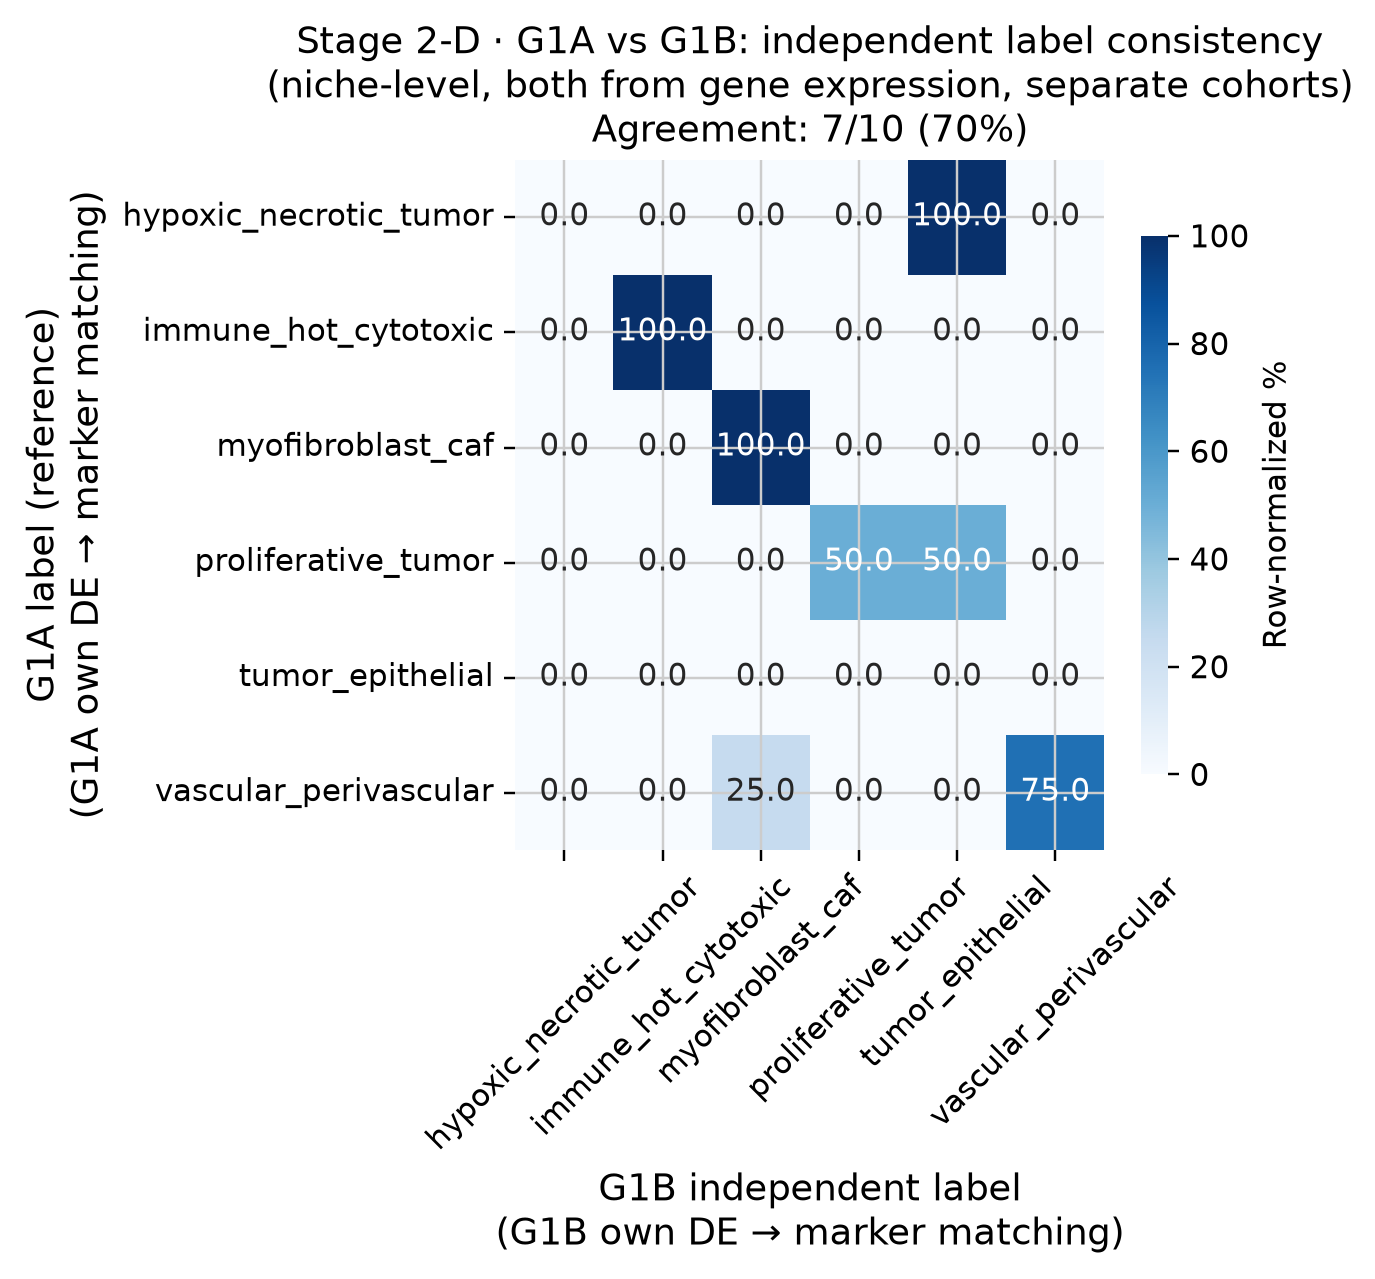

Saved: /workspace/spie2027/outputs/v1/nn/g1ab_label_consistency_cm.png


In [ ]:
# Stage 2-D: Label consistency evaluation between G1A and G1B.
#
# Conceptual framing
# ------------------
# Niche IDs are derived purely from H&E image features (DGI + clustering).
# Niche labels are derived independently from Xenium DE genes (marker matching)
# — separately for G1A and G1B patients.
#
# PRIMARY claim:  "The same H&E-defined cluster gets the same biological label
#                  from two independent patient cohorts using gene expression alone."
# SECONDARY (not shown): projected labels are trivially 100% (same ID → same label).

consistency_df = g1a_niche_labels[["niche_group", "niche_label"]].rename(
    columns={"niche_label": "label_g1a"}
).merge(
    g1b_niche_labels[["niche_group", "niche_label_projected", "niche_label_independent"]].rename(
        columns={"niche_label_projected": "label_g1b_projected",
                 "niche_label_independent": "label_g1b_independent"}),
    on="niche_group", how="inner",
)
consistency_df["label_g1a"]             = harmonize_label_series(consistency_df["label_g1a"].fillna(""))
consistency_df["label_g1b_projected"]   = harmonize_label_series(consistency_df["label_g1b_projected"].fillna(""))
consistency_df["label_g1b_independent"] = harmonize_label_series(consistency_df["label_g1b_independent"].fillna(""))
consistency_df["label_g1b"]             = consistency_df["label_g1b_projected"]
consistency_df["exact_match_independent"] = consistency_df["label_g1a"] == consistency_df["label_g1b_independent"]
consistency_df["exact_match_projected"]   = consistency_df["label_g1a"] == consistency_df["label_g1b_projected"]
consistency_df["exact_match"]             = consistency_df["exact_match_projected"]

n_shared             = len(consistency_df)
n_match_independent  = int(consistency_df["exact_match_independent"].sum())
n_match_projected    = int(consistency_df["exact_match_projected"].sum())
agree_rate_independent = n_match_independent / max(n_shared, 1)
agree_rate_projected   = n_match_projected   / max(n_shared, 1)

print(f"Shared niche IDs : {n_shared}")
print()
print(f"[PRIMARY]   Independent agreement  (G1A label vs G1B own DE label) : "
      f"{n_match_independent}/{n_shared}  ({agree_rate_independent:.2%})")
print(f"            → Real scientific signal: same H&E cluster, independently annotated.")
print()
print(f"[SECONDARY] Projected agreement (trivially 100% by construction — informational only):")
print(f"            {n_match_projected}/{n_shared}  ({agree_rate_projected:.2%})")
print()
print(consistency_df[["niche_group", "label_g1a", "label_g1b_independent",
                       "exact_match_independent"]].to_string(index=False))

consistency_df.to_csv(CFG["nn_dir"] / "g1ab_label_consistency.csv", index=False)

# ── Confusion matrix — row-normalised % (independent labels only) ──────────
if n_shared >= 2:
    indep_labels = sorted(set(consistency_df["label_g1a"]) | set(consistency_df["label_g1b_independent"]))
    cm_counts = confusion_matrix(consistency_df["label_g1a"],
                                 consistency_df["label_g1b_independent"],
                                 labels=indep_labels)
    _, _, cm_indep_df = plot_confusion_matrix_pct(
        cm_counts, indep_labels,
        title=(f"Stage 2-D · G1A vs G1B: independent label consistency\n"
               f"(niche-level, both from gene expression, separate cohorts)\n"
               f"Agreement: {n_match_independent}/{n_shared} ({agree_rate_independent:.0%})"),
        xlabel="G1B independent label\n(G1B own DE → marker matching)",
        ylabel="G1A label (reference)\n(G1A own DE → marker matching)",
        outpath=CFG["nn_dir"] / "g1ab_label_consistency_cm.png",
    )
    print("Saved:", CFG["nn_dir"] / "g1ab_label_consistency_cm.png")
else:
    print("Too few shared niches to plot confusion matrix.")


### Stage 2-E · Per-Slide Instance Consistency (Error Distribution View)

Stage 2-D pools all cells per niche across slides (n = 10 comparison pairs).
Here each **(slide × niche)** pair is an independent DE run — 3 G1A slides × 10 niches = 30 instances,
and 3 G1B slides × 10 niches = 30 instances.

**What this adds:**
- **(A) Intra-cohort** — do G1A's three slides agree on the label for niche_k?
- **(B) Cross-cohort** — does each G1B slide agree with G1A's pooled label?

**Important caveat:** the 30 instances are **not independent** (same 10 niche types × 3 slides).
The confusion matrix here shows the *error distribution pattern*, not a statistically valid accuracy.
Use Stage 2-D (n = 10) for the primary agreement rate.

In [ ]:
# Stage 2-E: Per-slide instance label reliability check.
# Each G1A slide × niche and G1B slide × niche is labelled independently (its own DE + marker
# overlap).  Agreement with the pooled-G1A label (Stage 1-B) and between G1A slides and G1B
# slides is a proxy for how reproducible the marker signal is across individual sections.

print("STAGE 2-E: Per-instance label reliability (G1A slides, G1B slides)")
print(f"  Minimum cells per (slide × niche) to run DE: {MIN_CELLS_PER_INSTANCE}")

# ── (A) Run per-instance labeling ─────────────────────────────────────────────
g1a_instance_labels = _run_per_instance_labeling(
    adata_g1a, G1A_STEMS, g1_niche_cols, marker_catalog, "G1A",
    min_cells=MIN_CELLS_PER_INSTANCE,
)
g1b_instance_labels = _run_per_instance_labeling(
    adata_g1b, G1B_STEMS, g1_niche_cols, marker_catalog, "G1B",
    min_cells=MIN_CELLS_PER_INSTANCE,
)
valid_g1a = g1a_instance_labels[~g1a_instance_labels["niche_label"].isin(
    ["skipped_too_few_cells", "no_de_genes"])].copy()
valid_g1b = g1b_instance_labels[~g1b_instance_labels["niche_label"].isin(
    ["skipped_too_few_cells", "no_de_genes"])].copy()

# ── (B) Intra-cohort: compare each G1A instance label to the pooled G1A label ─
pooled_ref = dict(zip(g1a_niche_labels["niche_group"], g1a_niche_labels["niche_label"]))
valid_g1a["pooled_label"] = valid_g1a["niche_group"].map(pooled_ref)
intra_match = (harmonize_label_series(valid_g1a["niche_label"]) ==
               harmonize_label_series(valid_g1a["pooled_label"]))
intra_n_match = int(intra_match.sum())
intra_n_total = len(valid_g1a)
print(f"\n  (B) G1A slide instances vs pooled G1A label: "
      f"{intra_n_match}/{intra_n_total} = {intra_n_match/intra_n_total:.0%} agreement")

# ── (C) Cross-cohort: modal G1A label vs modal G1B label per niche ────────────
modal_g1a = (valid_g1a.groupby("niche_group")["niche_label"]
             .agg(lambda s: s.value_counts().idxmax()).rename("modal_g1a"))
modal_g1b = (valid_g1b.groupby("niche_group")["niche_label"]
             .agg(lambda s: s.value_counts().idxmax()).rename("modal_g1b"))
instance_cross = pd.concat([modal_g1a, modal_g1b], axis=1).dropna()
cross_match = (harmonize_label_series(instance_cross["modal_g1a"]) ==
               harmonize_label_series(instance_cross["modal_g1b"]))
cross_n_match = int(cross_match.sum())
cross_n_niches = len(instance_cross)
print(f"  (C) Modal G1A label vs modal G1B label: "
      f"{cross_n_match}/{cross_n_niches} niches match")

# ── (D) Build inst_cm_df and plot ─────────────────────────────────────────────
inst_cm_rows = []
for _, row in valid_g1b.iterrows():
    ref = pooled_ref.get(row["niche_group"])
    if ref:
        inst_cm_rows.append({"ref_label": ref, "inst_label": row["niche_label"]})
inst_cm_df = pd.DataFrame(inst_cm_rows)

if len(inst_cm_df) >= 2:
    # Use only ref_labels (pooled G1A labels) as row labels so every row sums to 100%.
    # Instance labels that appear only in predictions but not in the reference would
    # produce zero-sum rows if included.
    all_inst_labels = sorted(set(inst_cm_df["ref_label"]))
    cm_inst_counts  = confusion_matrix(inst_cm_df["ref_label"], inst_cm_df["inst_label"],
                                       labels=all_inst_labels)
    n_correct   = int(np.diag(cm_inst_counts).sum())
    n_total_cm  = int(cm_inst_counts.sum())

    _, _, _ = plot_confusion_matrix_pct(
        cm_inst_counts, all_inst_labels,
        title=(f"Stage 2-E · Error distribution: G1A pooled vs G1B per-slide\n"
               f"n={n_total_cm} (10 niches × {len(G1B_STEMS)} slides — NOT independent)\n"
               f"Niche-level agreement (Stage 2-D): {n_match_independent}/{n_shared} "
               f"= {agree_rate_independent:.0%}"),
        xlabel="G1B instance label\n(one point per G1B slide × niche)",
        ylabel="G1A pooled label (reference)\n(G1A all-slides DE → marker matching)",
        outpath=CFG["nn_dir"] / "g1ab_instance_label_cm.png",
    )
    print(f"Instance CM: {n_correct}/{n_total_cm} on diagonal")
    print("Saved:", CFG["nn_dir"] / "g1ab_instance_label_cm.png")

else:
    print("Insufficient instance rows for CM — check MIN_CELLS_PER_INSTANCE.")

STAGE 2-E: Per-instance label reliability (G1A slides, G1B slides)
  Minimum cells per (slide × niche) to run DE: 30


KeyboardInterrupt: 

---

## Stage 3 · Train Neural Network on G1 (H&E Features → Niche Labels)

### Scientific rationale

Stage 2 confirmed that cell-neighbor composition (H&E features) reliably identifies biological
niche type across G1A and G1B. Now we train a neural network that learns:

$$
f_\theta(\phi_i) \rightarrow y_i
$$

where $\phi_i \in \mathbb{R}^{2d}$ is the per-niche mean+std feature vector and $y_i$ is the
G1A-derived human-readable label. Training uses **all of G1** (P1–P6).

### NN architecture

A simple MLP:
$$
h^{(1)} = \text{ReLU}(W_1 z + b_1), \quad
h^{(2)} = \text{ReLU}(W_2 h^{(1)} + b_2), \quad
\hat{y} = \text{softmax}(W_3 h^{(2)} + b_3)
$$
Cross-entropy loss:
$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \hat{p}(y_i | \phi_i)
$$

---

### Stage 3-A · Build G1 Feature Vectors

Each (G1 slide × niche) pair is summarized as a vector $\phi_i = [\mu, \sigma]$ over the cells
in that niche. Sampling augmentation bootstraps additional rows from the same (slide, niche) pool
to mitigate the small base sample size (60 base rows = 6 slides × 10 niches).

In [ ]:
# Stage 3-A: Build per-sample, per-niche feature vectors for all of G1.
# Each vector = [mean_1, ..., mean_d, std_1, ..., std_d] over cells in that niche.
# Label comes from G1A-derived labels (same niche IDs apply to G1B).

# Merge G1A + G1B into one AnnData with sample_id tracking.
adata_g1 = sc.concat(
    [adata_g1a, adata_g1b],
    join="inner", merge="same",
    label="cohort_key",
    keys=["g1a", "g1b"],
    index_unique="__"
)
# Restore sample_id (sc.concat may overwrite it with cohort_key).
adata_g1.obs["sample_id"] = (
    adata_g1a.obs["sample_id"].tolist() +
    adata_g1b.obs["sample_id"].tolist()
)

# Label map: niche_group → human-readable label (from G1A derivation).
label_map_g1 = dict(zip(g1a_niche_labels["niche_group"], g1a_niche_labels["niche_label"]))

obs_g1     = adata_g1.obs.copy()
vector_rows = []
rng = np.random.default_rng(CFG["seed"])

for sample_id in G1_STEMS:
    sample_obs = obs_g1.loc[obs_g1["sample_id"] == sample_id].copy()
    if sample_obs.empty:
        print(f"  WARNING: no cells found for {sample_id} — skipping.")
        continue

    sub_group = "g1a" if sample_id in G1A_STEMS else "g1b"

    for niche_col in g1_niche_cols:
        if niche_col not in label_map_g1:
            continue

        membership = pd.to_numeric(sample_obs[niche_col], errors="coerce").fillna(0).astype(int)
        mask    = membership.eq(1)
        n_cells = int(mask.sum())
        if n_cells == 0:
            continue

        feat     = sample_obs.loc[mask, g1_feat_cols].apply(pd.to_numeric, errors="coerce")
        mean_vec = feat.mean(axis=0, skipna=True).to_numpy(dtype=float)
        std_vec  = feat.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)
        vec      = np.concatenate([mean_vec, std_vec]).tolist()
        row_key  = f"{sample_id}__{niche_col}"

        vector_rows.append({
            "sample_id":   sample_id,
            "sub_group":   sub_group,
            "niche_group": niche_col,
            "niche_label": label_map_g1[niche_col],
            "n_cells":     n_cells,
            "vector":      vec,
            "row_key":     row_key,
            "source":      "base",
            "aug_iter":    0,
        })

        # Sampling augmentation: bootstrap additional rows from the same (sample, niche) pool.
        use_aug    = bool(CFG.get("nn_use_sampling_augmentation", False))
        aug_rpts   = int(CFG.get("nn_aug_repeats", 0))
        aug_frac   = float(CFG.get("nn_aug_sample_frac", 0.7))
        aug_mincells = int(CFG.get("nn_aug_min_cells", 12))
        aug_replace  = bool(CFG.get("nn_aug_replace", True))
        if use_aug and aug_rpts > 0 and n_cells >= aug_mincells:
            n_draw     = max(2, int(np.ceil(n_cells * aug_frac)))
            do_replace = aug_replace or (n_draw > n_cells)
            for k in range(1, aug_rpts + 1):
                draw_idx = rng.choice(feat.index.to_numpy(), size=n_draw, replace=do_replace)
                feat_draw = feat.loc[draw_idx]
                mean_aug = feat_draw.mean(axis=0, skipna=True).to_numpy(dtype=float)
                std_aug  = feat_draw.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)
                vec_aug  = np.concatenate([mean_aug, std_aug]).tolist()
                vector_rows.append({
                    "sample_id":   sample_id,
                    "sub_group":   sub_group,
                    "niche_group": niche_col,
                    "niche_label": label_map_g1[niche_col],
                    "n_cells":     n_cells,
                    "vector":      vec_aug,
                    "row_key":     row_key,
                    "source":      "sample_aug",
                    "aug_iter":    k,
                })

g1_vectors_df = pd.DataFrame(vector_rows)
g1_vectors_df.to_csv(CFG["nn_dir"] / "g1_vectors.csv", index=False)

n_base = int((g1_vectors_df["source"] == "base").sum())
n_aug  = int((g1_vectors_df["source"] != "base").sum())
print(f"G1 vector rows built: {len(g1_vectors_df)}")
print(f"  Base rows         : {n_base}")
print(f"  Augmented rows    : {n_aug}")
print(f"Feature dimension  : {len(g1_feat_cols)} features → vector length {2*len(g1_feat_cols)}")
print(f"Niche label classes: {sorted(g1_vectors_df['niche_label'].unique())}")


G1 vector rows built: 240
  Base rows         : 60
  Augmented rows    : 180
Feature dimension  : 18 features → vector length 36
Niche label classes: ['hypoxic_necrotic_tumor', 'immune_hot_cytotoxic', 'myofibroblast_caf', 'proliferative_tumor', 'vascular_perivascular']


### Stage 3-B · Encode Labels, Scale Features, Build Datasets

Encode niche labels as integer class IDs using the G1A canonical label file.
Fit `StandardScaler` on training rows only to prevent data leakage.
Base rows are split 80/20 (train/val); augmentation rows are attached to the train side only.

In [ ]:
# Stage 3-B: Encode labels, scale features, build PyTorch datasets.
# Standardization formula: z = (x - μ) / σ, fit on G1 training data only.
#
# Base rows are split 80/20 (train/val); augmentation rows go to train only
# to prevent leakage from the same (sample, niche) pair into validation.
from sklearn.model_selection import train_test_split

g1_vectors_df = g1_vectors_df.copy()

# ── Encode niche labels from the canonical G1A label file ─────────────────────
canonical_map = {}
canonical_path = CFG["outdir_g1a"] / "niche_labels.csv"
if canonical_path.exists():
    _canon_df = pd.read_csv(canonical_path)
    if {"niche_group", "niche_label"}.issubset(_canon_df.columns):
        canonical_map = dict(
            zip(
                _canon_df["niche_group"].astype(str).str.strip(),
                _canon_df["niche_label"].astype(str).str.strip(),
            )
        )

class_target = g1_vectors_df["niche_group"].astype(str).str.strip().map(canonical_map)
if class_target.isna().any():
    fallback = harmonize_label_series(g1_vectors_df["niche_label"].fillna("unknown").astype(str))
    class_target = class_target.fillna(fallback)
class_target = class_target.astype(str)
g1_vectors_df["niche_label"] = class_target

if class_target.nunique() < 2:
    print("Only one unique niche label detected; falling back to niche_group IDs for training.")
    class_target = g1_vectors_df["niche_group"].fillna("unknown").astype(str)
if class_target.nunique() == 0:
    raise RuntimeError("No label classes found in G1 feature vectors.")

g1_labels = sorted(class_target.unique().tolist())
label_encoder = LabelEncoder().fit(g1_labels)
g1_vectors_df["class_id"] = label_encoder.transform(class_target)

# ── Build feature matrix ───────────────────────────────────────────────────────
X_g1 = np.vstack(g1_vectors_df["vector"].tolist()).astype(np.float32)
X_g1 = np.nan_to_num(X_g1, nan=0.0, posinf=0.0, neginf=0.0)
y_g1 = g1_vectors_df["class_id"].to_numpy(dtype=np.int64)

# ── Train/validation split (base rows only; aug rows go to train side) ─────────
base_mask = g1_vectors_df["source"].astype(str).eq("base")
base_idx  = np.where(base_mask.to_numpy())[0]
if len(base_idx) == 0:
    raise RuntimeError("No base rows found for train/validation split.")

y_base = y_g1[base_idx]
idx_tr_base, idx_val = train_test_split(
    base_idx, test_size=0.2, random_state=CFG["seed"],
    stratify=y_base if len(np.unique(y_base)) > 1 else None,
)

train_base_keys = set(g1_vectors_df.iloc[idx_tr_base]["row_key"].astype(str).tolist())
aug_mask = ~base_mask
aug_idx_train = np.where(
    aug_mask.to_numpy() & g1_vectors_df["row_key"].astype(str).isin(train_base_keys).to_numpy()
)[0]
idx_tr = np.concatenate([idx_tr_base, aug_idx_train]) if len(aug_idx_train) else idx_tr_base

# ── Scale (fit on train only) ──────────────────────────────────────────────────
scaler  = StandardScaler().fit(X_g1[idx_tr])
X_g1_s  = scaler.transform(X_g1).astype(np.float32)
X_tr, y_tr   = X_g1_s[idx_tr], y_g1[idx_tr]
X_val, y_val = X_g1_s[idx_val], y_g1[idx_val]

class_names = list(label_encoder.classes_)
num_classes = len(class_names)
input_dim   = X_tr.shape[1]
if num_classes < 1:
    raise RuntimeError("Need at least 1 label class to train.")

# ── PyTorch datasets ──────────────────────────────────────────────────────────
train_dataset = TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

n_base_total = int(base_mask.sum())
n_aug_total  = int((~base_mask).sum())
n_base_train = int(np.isin(idx_tr, base_idx).sum())
n_aug_train  = int(np.isin(idx_tr, np.where(~base_mask.to_numpy())[0]).sum())

print("Model inputs ready.")
print(f"  Input dimension : {input_dim}")
print(f"  Num classes     : {num_classes}  →  {class_names}")
print(f"  Base rows total : {n_base_total}")
print(f"  Aug rows total  : {n_aug_total}")
print(f"  Training rows   : {len(X_tr)}  (base={n_base_train}, aug={n_aug_train})")
print(f"  Validation rows : {len(X_val)}  (base only)")


Model inputs ready.
  Input dimension : 36
  Num classes     : 5  →  [np.str_('hypoxic_necrotic_tumor'), np.str_('immune_hot_cytotoxic'), np.str_('myofibroblast_caf'), np.str_('proliferative_tumor'), np.str_('vascular_perivascular')]
  Base rows total : 60
  Aug rows total  : 180
  Training rows   : 192  (base=48, aug=144)
  Validation rows : 12  (base only)


### Stage 3-C · Define MLP and Train

MLP with two hidden layers (256 → 128), BatchNorm + ReLU + Dropout.  
Set `RELOAD_MODEL = True` to skip training and reload saved artifacts from disk.

Using device: cpu
RELOAD_MODEL : False


/opt/anaconda3/envs/spie2027/lib/python3.12/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  Epoch   1/50  loss=1.4649  val_acc=0.9167
  Epoch  10/50  loss=0.1930  val_acc=1.0000
  Epoch  20/50  loss=0.0825  val_acc=1.0000
  Epoch  30/50  loss=0.0366  val_acc=1.0000
  Epoch  40/50  loss=0.0209  val_acc=1.0000
  Epoch  50/50  loss=0.0229  val_acc=1.0000

Training complete.  Final val acc: 1.0000
  Saved: /workspace/spie2027/outputs/v1/nn/niche_mlp.pt


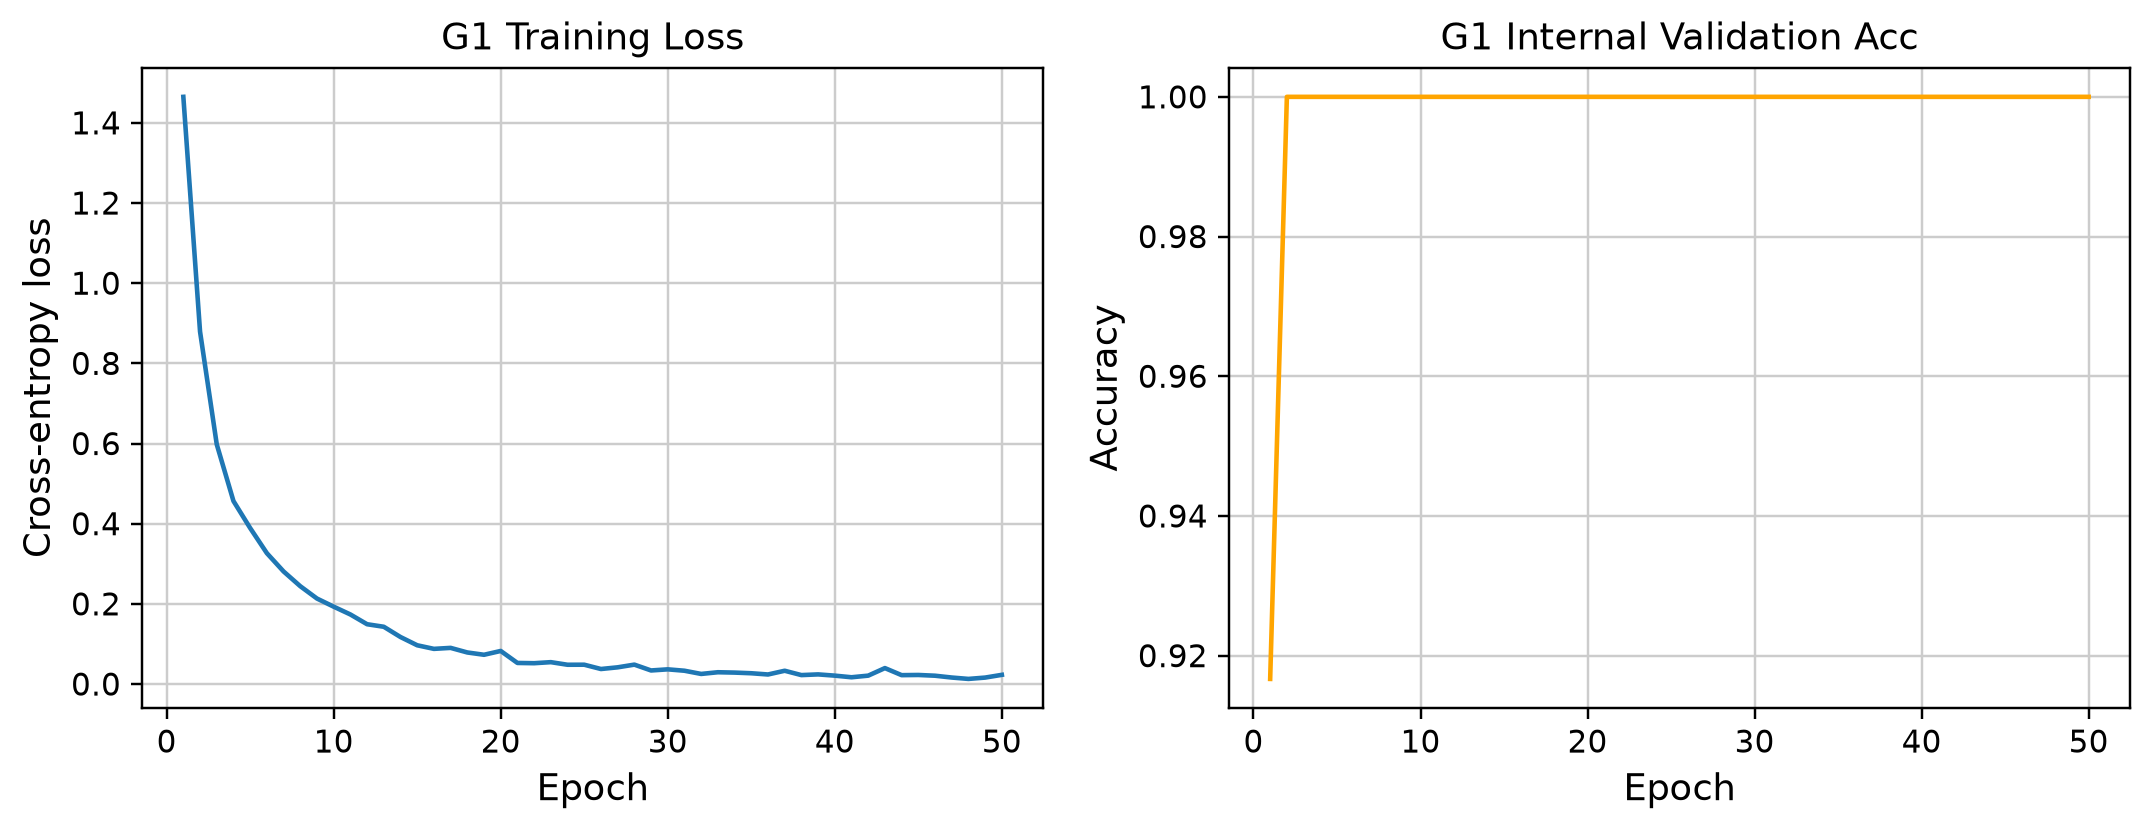

In [ ]:
# Stage 3-C: Define MLP and train on G1 (or reload from disk).
#
# ── USER FLAG ─────────────────────────────────────────────────────────────
# RELOAD_MODEL = False  → train from scratch (uses Stage 3-B outputs)
# RELOAD_MODEL = True   → skip training; load saved model/scaler/encoder
# ─────────────────────────────────────────────────────────────────────────
RELOAD_MODEL = False   # <── change to True to resume without retraining

import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("RELOAD_MODEL :", RELOAD_MODEL)


class NicheMLP(nn.Module):
    """MLP classifier: input → BatchNorm+ReLU+Dropout hidden layers → output."""
    def __init__(self, input_dim, hidden_sizes, num_classes, dropout):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


if RELOAD_MODEL:
    model_path  = CFG["nn_dir"] / "niche_mlp.pt"
    scaler_path = CFG["nn_dir"] / "scaler.pkl"
    le_path     = CFG["nn_dir"] / "label_encoder.pkl"
    missing = [p for p in [model_path, scaler_path, le_path] if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Cannot reload — missing: {missing}")
    with open(scaler_path, "rb") as f: scaler = pickle.load(f)
    with open(le_path, "rb") as f: label_encoder = pickle.load(f)
    class_names = list(label_encoder.classes_)
    num_classes  = len(class_names)
    state     = torch.load(model_path, map_location=device)
    input_dim = state["net.0.weight"].shape[1]
    model = NicheMLP(input_dim, CFG["nn_hidden"], num_classes, CFG["nn_dropout"]).to(device)
    model.load_state_dict(state)
    model.eval()
    print("Model reloaded.")
    print(f"  Classes   : {class_names}")
    print(f"  Input dim : {input_dim}")

else:
    model = NicheMLP(input_dim, CFG["nn_hidden"], num_classes, CFG["nn_dropout"]).to(device)
    optimizer    = torch.optim.Adam(model.parameters(), lr=CFG["nn_lr"],
                                    weight_decay=CFG["nn_weight_decay"])
    criterion    = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=CFG["nn_batch_size"],
                              shuffle=True, drop_last=False)
    history = {"epoch": [], "train_loss": [], "val_acc": []}

    for epoch in range(1, CFG["nn_epochs"] + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_loss = epoch_loss / len(train_dataset)
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).argmax(1).cpu().numpy()
        val_acc = accuracy_score(y_val, val_pred)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{CFG['nn_epochs']}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    torch.save(model.state_dict(), CFG["nn_dir"] / "niche_mlp.pt")
    with open(CFG["nn_dir"] / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
    with open(CFG["nn_dir"] / "label_encoder.pkl", "wb") as f: pickle.dump(label_encoder, f)
    print(f"\nTraining complete.  Final val acc: {history['val_acc'][-1]:.4f}")
    print(f"  Saved: {CFG['nn_dir'] / 'niche_mlp.pt'}")

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(CFG["nn_dir"] / "training_history.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"])
    axes[0].set_xlabel("Epoch",               fontsize=_FS_LABEL)
    axes[0].set_ylabel("Cross-entropy loss",   fontsize=_FS_LABEL)
    axes[0].set_title("G1 Training Loss",      fontsize=_FS_TITLE)
    axes[0].tick_params(labelsize=_FS_TICK)
    axes[1].plot(hist_df["epoch"], hist_df["val_acc"], color="orange")
    axes[1].set_xlabel("Epoch",                    fontsize=_FS_LABEL)
    axes[1].set_ylabel("Accuracy",                 fontsize=_FS_LABEL)
    axes[1].set_title("G1 Internal Validation Acc", fontsize=_FS_TITLE)
    axes[1].tick_params(labelsize=_FS_TICK)
    fig.tight_layout()
    fig.savefig(CFG["nn_dir"] / "g1_training_curve.png", dpi=300, bbox_inches="tight")
    plt.show()


---

## Stage 4 · Cross-Group Transfer: Predict G2 Niche Types from H&E Features

### Key design

G2 was processed by an **independent** WSInsight run, so its niche IDs have no direct correspondence
to G1 niche IDs. The NN trained on G1 does **not** use niche IDs — it uses the continuous H&E
neighbor-composition feature vector $\phi_i$, which encodes biology regardless of niche numbering.

**Stage 4 workflow:**
1. Build G2 feature vectors (same formula as G1).
2. Apply the G1-trained NN → predicted G1-space niche labels for G2 niches.
3. Independently run DE → marker-p on G2 → ground-truth G2 niche labels.
4. Compare predictions vs ground truth → AUC / confusion matrix (see Math A/B above).

If the NN generalizes, it means H&E neighbor composition captures transferable biology.

---

### Stage 4-A · Build G2 Feature Vectors

Build one feature vector per (G2 slide × G2 niche) using the same mean+std formula as G1.
G2's `niche_feature_k*` columns are used; only columns shared with G1 contribute.

In [ ]:
# Stage 4-A: Build G2 feature vectors using the same mean+std formula.
# G2 uses g2_feat_cols (feature columns from G2's own wsinsight run).
# We must check that G2 features are in the same semantic space as G1 features.
# If the wsinsight run uses consistent feature extraction, the column names will match.

obs_g2 = adata_g2.obs.copy()
g2_vector_rows = []

# Use G1 feature column names as the reference; only keep G2 columns that match.
shared_feat_cols = [c for c in g1_feat_cols if c in g2_feat_cols]
print(f"Shared feature columns between G1 and G2: {len(shared_feat_cols)} / "
      f"(G1={len(g1_feat_cols)}, G2={len(g2_feat_cols)})")
if len(shared_feat_cols) < len(g1_feat_cols):
    print("WARNING: G2 is missing some G1 feature columns. "
          "This may reduce prediction quality.")

for sample_id in G2_STEMS:
    sample_obs = obs_g2.loc[obs_g2["sample_id"] == sample_id].copy()
    if sample_obs.empty:
        print(f"  WARNING: {sample_id} not found in G2 AnnData — skipping.")
        continue

    for niche_col in g2_niche_cols:
        membership = pd.to_numeric(sample_obs[niche_col], errors="coerce").fillna(0).astype(int)
        mask    = membership.eq(1)
        n_cells = int(mask.sum())
        if n_cells == 0:
            continue

        feat = sample_obs.loc[mask, shared_feat_cols].apply(pd.to_numeric, errors="coerce")
        mean_vec = feat.mean(axis=0, skipna=True).to_numpy(dtype=float)
        std_vec  = feat.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)

        # Pad zeros for any G1 feature columns absent in G2.
        if len(shared_feat_cols) < len(g1_feat_cols):
            full_mean = np.zeros(len(g1_feat_cols), dtype=float)
            full_std  = np.zeros(len(g1_feat_cols), dtype=float)
            for i, col in enumerate(g1_feat_cols):
                if col in shared_feat_cols:
                    j = shared_feat_cols.index(col)
                    full_mean[i] = mean_vec[j]
                    full_std[i]  = std_vec[j]
            vec = np.concatenate([full_mean, full_std]).tolist()
        else:
            vec = np.concatenate([mean_vec, std_vec]).tolist()

        g2_vector_rows.append({
            "sample_id":   sample_id,
            "niche_group": niche_col,  # G2's own niche IDs
            "n_cells":     n_cells,
            "vector":      vec,
        })

g2_vectors_df = pd.DataFrame(g2_vector_rows)
g2_vectors_df.to_csv(CFG["nn_dir"] / "g2_vectors.csv", index=False)
print(f"\nG2 vector rows built: {len(g2_vectors_df)}")

Shared feature columns between G1 and G2: 18 / (G1=18, G2=18)

G2 vector rows built: 60


### Stage 4-B · Apply Trained NN to G2

Apply the G1-trained model (with the G1 scaler — **never refit on G2**) to G2 feature vectors.
The model outputs a probability distribution over the 5 G1 niche label classes for each G2 (slide × niche).

In [ ]:
# Stage 4-B: Run NN on G2 to predict G1-space niche labels.
# The scaler and label_encoder are the G1-trained objects from Stage 3.

model.eval()  # switch to inference mode (disables dropout / batchnorm training behavior)

X_g2 = np.vstack(g2_vectors_df["vector"].tolist()).astype(np.float32)
X_g2 = np.nan_to_num(X_g2, nan=0.0, posinf=0.0, neginf=0.0)

# Apply the G1 scaler (fit on G1 training data — never refit on G2).
X_g2_s = scaler.transform(X_g2).astype(np.float32)

with torch.no_grad():
    logits_g2 = model(torch.tensor(X_g2_s, dtype=torch.float32, device=device))
    probs_g2  = torch.softmax(logits_g2, dim=1).cpu().numpy()
    preds_g2  = probs_g2.argmax(axis=1)

# Decode integer predictions to human-readable labels.
pred_labels_g2 = label_encoder.inverse_transform(preds_g2)

# Attach predictions to the G2 vector table.
g2_vectors_df["predicted_label"] = pred_labels_g2
for idx, cls in enumerate(class_names):
    g2_vectors_df[f"prob_{cls}"] = probs_g2[:, idx]

g2_vectors_df.to_csv(CFG["nn_dir"] / "g2_predictions.csv", index=False)

print("G2 NN predictions complete.")
print("Predicted label distribution:")
print(g2_vectors_df["predicted_label"].value_counts().to_string())

G2 NN predictions complete.
Predicted label distribution:
predicted_label
vascular_perivascular     24
proliferative_tumor       12
immune_hot_cytotoxic      11
hypoxic_necrotic_tumor     7
myofibroblast_caf          6


### Stage 4-C · Derive G2 Ground-Truth Labels

G2's Xenium data is now used to independently derive human-readable niche labels via
the same two-step pipeline used in Stages 1 and 2:

1. **Wilcoxon DE** — find genes that are significantly more active in each niche vs all others.
2. **Empirical-p labeling** — match the DE gene set to `nichemarkers-v1.csv` via the hypergeometric test.

The resulting labels are the **held-out ground truth** for Stage 4-E.
They were derived entirely from G2's own gene expression — the neural network never saw them.


In [ ]:
# Stage 4-C (step 1 of 2): Differential Expression on G2.
# Same procedure as Stage 1-A (G1A) and Stage 2-A (G1B) — Wilcoxon DE per niche.
print("\n" + "="*80)
print("STAGE 4-C: Differential Expression on G2 (cross-cohort target)")
print("="*80)
print(f"Strict filter  : p-value < {CFG['de_pval']}, log-fold-change > {CFG['de_logfc']}")
print(f"Relaxed filter : p-value < {CFG['de_pval_relaxed']}, log-fold-change > {CFG['de_logfc_relaxed']}")
print()

g2_markers_all, g2_markers_filt = run_de_for_group(
    adata_g2, g2_niche_cols, CFG["outdir_g2"], "G2"
)
n_filtered_total = sum(len(df) for df in g2_markers_filt.values())
print(f"Total tested: {len(g2_markers_all)} rows ({len(adata_g2.var_names)} genes × {len(g2_niche_cols)} niches)")
print(f"Filtered:     {n_filtered_total} gene-niche pairs passed thresholds")



STAGE 4-C: Differential Expression on G2 (cross-cohort target)
Strict filter  : p-value < 0.001, log-fold-change > 0.5
Relaxed filter : p-value < 0.01, log-fold-change > 0.25

Total tested: 2800 rows (280 genes × 10 niches)
Filtered:     666 gene-niche pairs passed thresholds


In [ ]:
# Stage 4-C (step 2 of 2): Marker-signature label assignment for G2.
# Same procedure as Stage 1-B (G1A) and Stage 2-B (G1B) — hypergeometric empirical-p.
print("Stage 4-C — Assigning biological labels to G2 niches (empirical p-value approach)...")

g2_niche_labels = run_marker_labeling_empirical_p(
    g2_niche_cols,
    g2_markers_filt,
    adata_g2,
    CFG["outdir_g2"],
    "G2",
    marker_catalog,
)

# Build a quick lookup dict: niche_group → niche_label.
# Used by Stage 4-D (consistency check) and Stage 4-E (evaluation).
g2_label_map = dict(
    zip(
        g2_niche_labels["niche_group"].astype(str).str.strip(),
        g2_niche_labels["niche_label"].astype(str).str.strip(),
    )
)

g2_niche_labels = g2_niche_labels.sort_values("niche_group").reset_index(drop=True)
g2_niche_labels.to_csv(CFG["outdir_g2"] / "niche_labels.csv", index=False)

print("\nG2 niche labels saved to:", CFG["outdir_g2"] / "niche_labels.csv")
print(g2_niche_labels.to_string(index=False))


Stage 4-C — Assigning biological labels to G2 niches (empirical p-value approach)...

G2 niche labels saved to: /workspace/spie2027/outputs/v1/g2_markers/niche_labels.csv
niche_group           niche_label  empirical_p  empirical_p_fdr  n_overlap       label_source
    niche_0  immune_hot_cytotoxic     0.000209         0.003760          4 marker_empirical_p
    niche_1      tumor_epithelial     0.094314         1.000000          3 marker_empirical_p
    niche_2 vascular_perivascular     0.000153         0.002756          5 marker_empirical_p
    niche_3   proliferative_tumor     0.000042         0.000749          5 marker_empirical_p
    niche_4 vascular_perivascular     0.000229         0.004114          5 marker_empirical_p
    niche_5   proliferative_tumor     0.005169         0.093047          5 marker_empirical_p
    niche_6      tumor_epithelial     0.089928         1.000000          3 marker_empirical_p
    niche_7 vascular_perivascular     0.000276         0.004969          5 ma

### Stage 4-D · G1A vs G2 Label Consistency (Niche-ID Sanity Check)

**What are we checking here?**  
G1A and G2 were processed in the **same combined WSInsight niche run** (all 12 samples together),
so `niche_group` ID *k* refers to the same H&E feature-space cluster in both groups.
We just used different patients' gene expression to decide what that cluster means biologically.

If the empirical-p labeling is working correctly, niche ID *k* should get the same name
whether we use G1A's cells or G2's cells as evidence.
This is a **sanity check on the labeling method** — it has nothing to do with the neural network.

This is the cross-group analogue of Stage 2-D (which did the same check for G1A vs G1B).


In [ ]:
# Stage 4-D: G1A vs G2 niche-ID label consistency.
# g1a_label_map was built in Stage 1-B; g2_label_map was built in Stage 4-C above.
# Both map niche_group → niche_label, derived independently from separate patient groups.
shared_ids_g1a_g2 = sorted(set(g1a_niche_labels["niche_group"]) & set(g2_niche_labels["niche_group"]))

g1a_g2_consistency = pd.DataFrame({
    "niche_group": shared_ids_g1a_g2,
    "label_g1a":   [g1a_label_map.get(nid) for nid in shared_ids_g1a_g2],
    "label_g2":    [g2_label_map.get(nid) for nid in shared_ids_g1a_g2],
})
g1a_g2_consistency["exact_match"] = (
    g1a_g2_consistency["label_g1a"] == g1a_g2_consistency["label_g2"]
)

n_match = int(g1a_g2_consistency["exact_match"].sum())
n_total = len(g1a_g2_consistency)
print(f"Shared niche IDs (G1A vs G2): {n_total}")
print(f"Exact label matches: {n_match}/{n_total}  ({100 * n_match / max(n_total, 1):.2f}%)")
print(g1a_g2_consistency.to_string(index=False))

g1a_g2_consistency.to_csv(CFG["nn_dir"] / "g1a_g2_label_consistency.csv", index=False)
print("Saved:", CFG["nn_dir"] / "g1a_g2_label_consistency.csv")

# ── Join G2 ground-truth labels onto g2_vectors_df for Stage 4-E evaluation ──
# g2_vectors_df has one row per (sample_id, niche_group) — the NN prediction unit.
# g2_niche_labels has one row per niche_group — the pooled empirical-p label for G2.
# The ground truth is G2's OWN empirical-p label (not G1's), so Stage 4-E answers:
# "Does the H&E feature pattern predict the same biology as G2's gene expression?"
_g2_gt = g2_niche_labels[["niche_group", "niche_label"]].rename(
    columns={"niche_label": "true_label_g2"}
)
_g2_gt["true_label_g2"] = harmonize_label_series(_g2_gt["true_label_g2"].fillna(""))
g2_vectors_df = g2_vectors_df.drop(columns=["true_label_g2"], errors="ignore").merge(
    _g2_gt, on="niche_group", how="left"
)
print(f"\nG2 ground-truth labels joined onto g2_vectors_df: "
      f"{g2_vectors_df['true_label_g2'].notna().sum()}/{len(g2_vectors_df)} rows")
print(g2_vectors_df[["sample_id", "niche_group", "predicted_label", "true_label_g2"]].to_string(index=False))


Shared niche IDs (G1A vs G2): 10
Exact label matches: 7/10  (70.00%)
niche_group              label_g1a              label_g2  exact_match
    niche_0   immune_hot_cytotoxic  immune_hot_cytotoxic         True
    niche_1 hypoxic_necrotic_tumor      tumor_epithelial        False
    niche_2  vascular_perivascular vascular_perivascular         True
    niche_3      myofibroblast_caf   proliferative_tumor        False
    niche_4  vascular_perivascular vascular_perivascular         True
    niche_5    proliferative_tumor   proliferative_tumor         True
    niche_6    proliferative_tumor      tumor_epithelial        False
    niche_7  vascular_perivascular vascular_perivascular         True
    niche_8   immune_hot_cytotoxic  immune_hot_cytotoxic         True
    niche_9  vascular_perivascular vascular_perivascular         True
Saved: /workspace/spie2027/outputs/v1/nn/g1a_g2_label_consistency.csv

G2 ground-truth labels joined onto g2_vectors_df: 60/60 rows
                             

### Stage 4-E · Cross-Group Evaluation: Confusion Matrix + AUC

Compare the NN's predicted labels (H&E only) against G2's empirical-p ground truth (gene expression only).

We evaluate **only on niche label types that appear in both G1 training and G2 ground truth** (seen labels), using the row-normalised confusion matrix and ROC-AUC defined in the Mathematical Background section. Rows with G2-only label types are reported separately as unseen coverage.


G2 niche rows with ground truth     : 60
  Rows with seen labels (evaluable)  : 48
  Rows with unseen labels (excluded) : 12

Cross-group accuracy  (G2 eval): 0.8542
Cross-group macro-F1  (G2 eval): 0.5246

Per-class classification report (G2):
                       precision    recall  f1-score  support
immune_hot_cytotoxic         1.0  0.916667  0.956522     12.0
proliferative_tumor          1.0  0.500000  0.666667     12.0
vascular_perivascular        1.0  1.000000  1.000000     24.0
micro avg                    1.0  0.854167  0.921348     48.0
macro avg                    1.0  0.805556  0.874396     48.0
weighted avg                 1.0  0.854167  0.905797     48.0


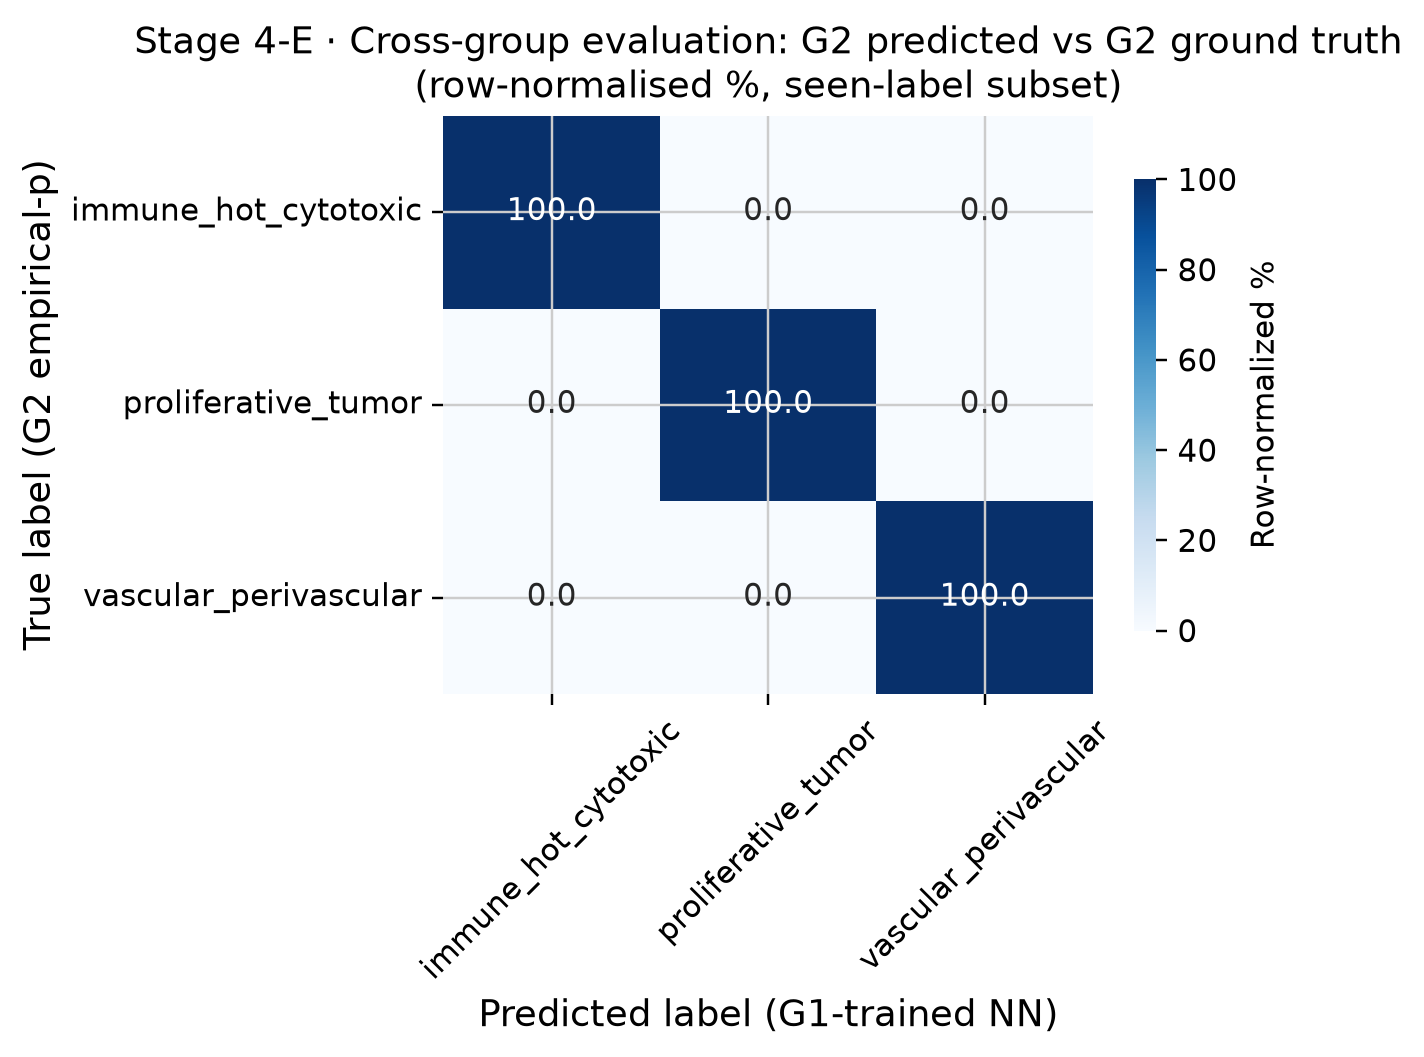

Saved: /workspace/spie2027/outputs/v1/nn/g2_confusion_matrix_heatmap.png


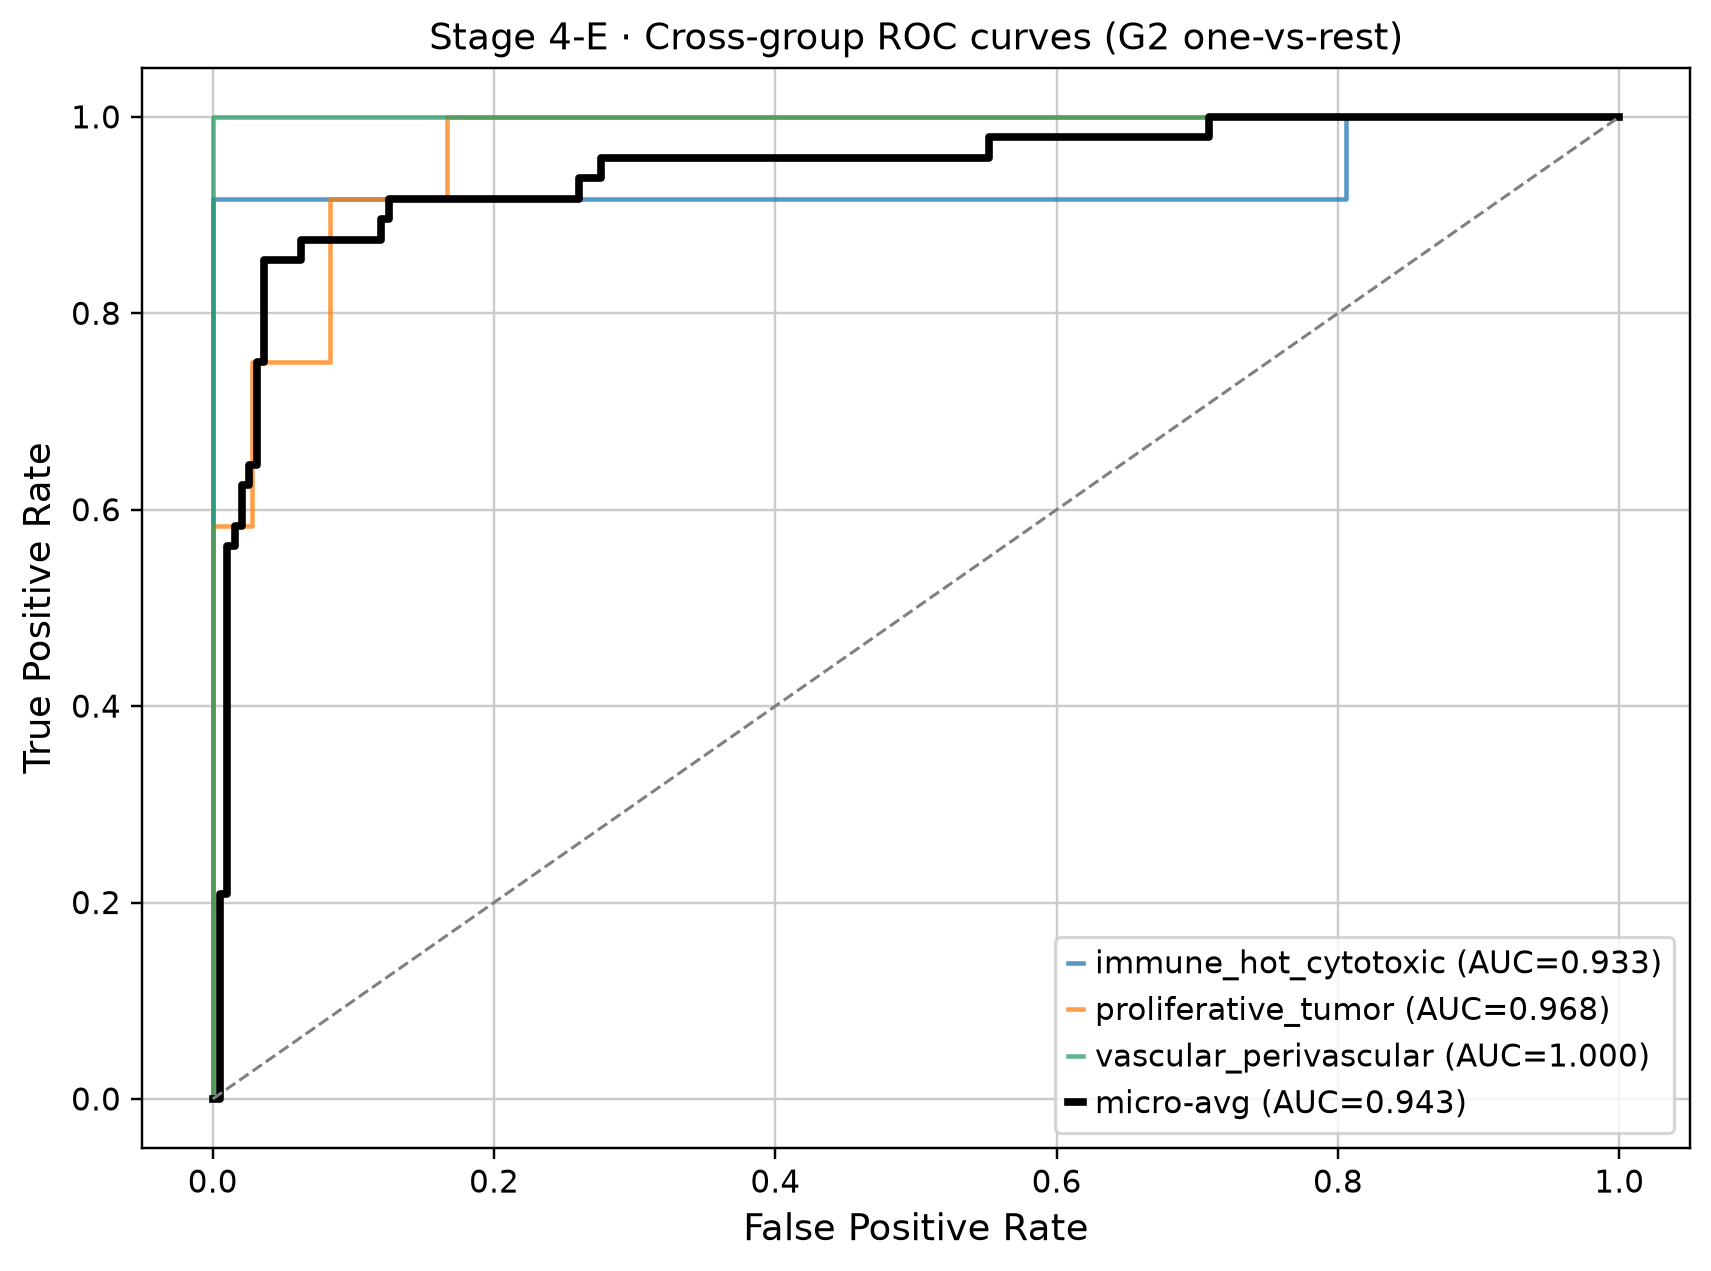


ROC-AUC per class (G2):
                class  roc_auc
 immune_hot_cytotoxic 0.932870
  proliferative_tumor 0.967593
vascular_perivascular 1.000000
        overall_micro 0.942600

Evaluation coverage summary:
 g2_niche_rows_total  g2_rows_with_truth  g2_rows_seen_labels  g2_rows_unseen_labels  accuracy  macro_f1  roc_auc_micro
                  60                  60                   48                     12  0.854167  0.524638         0.9426


In [ ]:
# Stage 4-E: Cross-group evaluation — NN predicted labels vs G2 empirical-p ground truth.
# See "Mathematical Background" (before Stage 2-D) for the CM and ROC-AUC formulas.

eval_df     = g2_vectors_df.dropna(subset=["true_label_g2"]).copy()
seen_mask   = eval_df["true_label_g2"].isin(class_names)
eval_seen   = eval_df.loc[seen_mask].copy()
eval_unseen = eval_df.loc[~seen_mask].copy()

print(f"G2 niche rows with ground truth     : {len(eval_df)}")
print(f"  Rows with seen labels (evaluable)  : {len(eval_seen)}")
print(f"  Rows with unseen labels (excluded) : {len(eval_unseen)}")

if eval_seen.empty:
    print("\nNo overlap between G2 true labels and G1 training labels.")
    print("Skipping CM/ROC — writing coverage summary only.")
    coverage = pd.DataFrame([{
        "g2_niche_rows_total":   len(g2_vectors_df),
        "g2_rows_with_truth":    len(eval_df),
        "g2_rows_seen_labels":   len(eval_seen),
        "g2_rows_unseen_labels": len(eval_unseen),
        "accuracy":  np.nan, "macro_f1": np.nan, "roc_auc_micro": np.nan,
    }])
    coverage.to_csv(CFG["nn_dir"] / "g2_eval_coverage.csv", index=False)
    print(coverage.to_string(index=False))

else:
    y_true_g2 = label_encoder.transform(eval_seen["true_label_g2"])
    y_pred_g2 = label_encoder.transform(eval_seen["predicted_label"])
    prob_cols  = [f"prob_{c}" for c in class_names]
    prob_mat   = eval_seen[prob_cols].to_numpy(dtype=np.float32)

    acc_g2 = accuracy_score(y_true_g2, y_pred_g2)
    f1_g2  = f1_score(y_true_g2, y_pred_g2, average="macro", zero_division=0)
    print(f"\nCross-group accuracy  (G2 eval): {acc_g2:.4f}")
    print(f"Cross-group macro-F1  (G2 eval): {f1_g2:.4f}")

    # Use only labels that actually appear in y_true so every CM row sums to 100%.
    # (Classes predicted by the NN but absent from G2 ground truth would produce
    # zero-sum rows if included, which cannot be row-normalised to 100%.)
    cm_labels = sorted(set(y_true_g2))
    cm_names  = label_encoder.inverse_transform(cm_labels)
    report_dict = classification_report(
        y_true_g2, y_pred_g2, labels=cm_labels, target_names=cm_names,
        output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T
    report_df.to_csv(CFG["nn_dir"] / "g2_classification_report.csv")
    print("\nPer-class classification report (G2):")
    print(report_df.to_string())

    # ── Confusion matrix (row-normalised %) ──────────────────────────────────
    cm_g2 = confusion_matrix(y_true_g2, y_pred_g2, labels=cm_labels)
    pd.DataFrame(cm_g2, index=cm_names, columns=cm_names).to_csv(
        CFG["nn_dir"] / "g2_confusion_matrix_counts.csv")

    _, _, cm_g2_pct_df = plot_confusion_matrix_pct(
        cm_g2, list(cm_names),
        title=(f"Stage 4-E · Cross-group evaluation: G2 predicted vs G2 ground truth\n"
               f"(row-normalised %, seen-label subset)"),
        xlabel="Predicted label (G1-trained NN)",
        ylabel="True label (G2 empirical-p)",
        outpath=CFG["nn_dir"] / "g2_confusion_matrix_heatmap.png",
    )
    cm_g2_pct_df.to_csv(CFG["nn_dir"] / "g2_confusion_matrix.csv")
    print("Saved:", CFG["nn_dir"] / "g2_confusion_matrix_heatmap.png")

    # ── ROC-AUC ──────────────────────────────────────────────────────────────
    y_bin_g2    = label_binarize(y_true_g2, classes=np.arange(num_classes))
    roc_records = []
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
    for idx in np.unique(y_true_g2):
        if y_bin_g2[:, idx].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin_g2[:, idx], prob_mat[:, idx])
        roc_auc_val = auc(fpr, tpr)
        roc_records.append({"class": class_names[idx], "roc_auc": roc_auc_val})
        ax_roc.plot(fpr, tpr, alpha=0.75, label=f"{class_names[idx]} (AUC={roc_auc_val:.3f})")
    fpr_micro, tpr_micro, _ = roc_curve(y_bin_g2.ravel(), prob_mat.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax_roc.plot(fpr_micro, tpr_micro, "k-", lw=2.5, label=f"micro-avg (AUC={auc_micro:.3f})")
    roc_records.append({"class": "overall_micro", "roc_auc": auc_micro})
    ax_roc.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    ax_roc.set_xlabel("False Positive Rate", fontsize=_FS_LABEL)
    ax_roc.set_ylabel("True Positive Rate",  fontsize=_FS_LABEL)
    ax_roc.set_title("Stage 4-E · Cross-group ROC curves (G2 one-vs-rest)", fontsize=_FS_TITLE)
    ax_roc.tick_params(labelsize=_FS_TICK)
    ax_roc.legend(loc="lower right", fontsize=_FS_TICK)
    fig_roc.tight_layout()
    fig_roc.savefig(CFG["nn_dir"] / "g2_roc_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    roc_df = pd.DataFrame(roc_records)
    roc_df.to_csv(CFG["nn_dir"] / "g2_roc_auc.csv", index=False)
    print("\nROC-AUC per class (G2):")
    print(roc_df.to_string(index=False))

    coverage = pd.DataFrame([{
        "g2_niche_rows_total":   len(g2_vectors_df),
        "g2_rows_with_truth":    len(eval_df),
        "g2_rows_seen_labels":   len(eval_seen),
        "g2_rows_unseen_labels": len(eval_unseen),
        "accuracy":      acc_g2,
        "macro_f1":      f1_g2,
        "roc_auc_micro": auc_micro,
    }])
    coverage.to_csv(CFG["nn_dir"] / "g2_eval_coverage.csv", index=False)
    print("\nEvaluation coverage summary:")
    print(coverage.to_string(index=False))


### Stage 4-F · G2 Per-Slide Instance Consistency (Error Distribution View)

Mirrors Stage 2-E for G2. G2 has **6 slides × 10 niches = 60 instances**.  
Each (slide, niche) pair is labelled independently via DE → empirical-p, then compared against G2's pooled label.

**Same caveat as Stage 2-E:** the 60 instances are NOT statistically independent — same 10 niche types × 6 slides.  
This reveals which niche types are ambiguous within G2, complementing the 10-point niche-level result in Stage 4-D.


Stage 4-F — G2 per-slide instance analysis...
  G2 instances with labels: 60/60

(A) Intra-G2 consistency: do G2 slides agree on label per niche?
niche_group           modal_label  n_instances  n_agree                                                                                                                                    labels
    niche_0  immune_hot_cytotoxic            6        5            tumor_epithelial, immune_hot_cytotoxic, immune_hot_cytotoxic, immune_hot_cytotoxic, immune_hot_cytotoxic, immune_hot_cytotoxic
    niche_1   proliferative_tumor            6        3                       tumor_epithelial, proliferative_tumor, proliferative_tumor, tumor_epithelial, tumor_epithelial, proliferative_tumor
    niche_2  immune_hot_cytotoxic            6        4      vascular_perivascular, immune_hot_cytotoxic, immune_hot_cytotoxic, immune_hot_cytotoxic, vascular_perivascular, immune_hot_cytotoxic
    niche_3     myofibroblast_caf            6        2                       

/tmp/ipykernel_4157112/2903463777.py:55: RuntimeWarning: invalid value encountered in divide
  cm_pct  = np.where(row_sum > 0, cm_arr / row_sum * 100.0, 0.0)


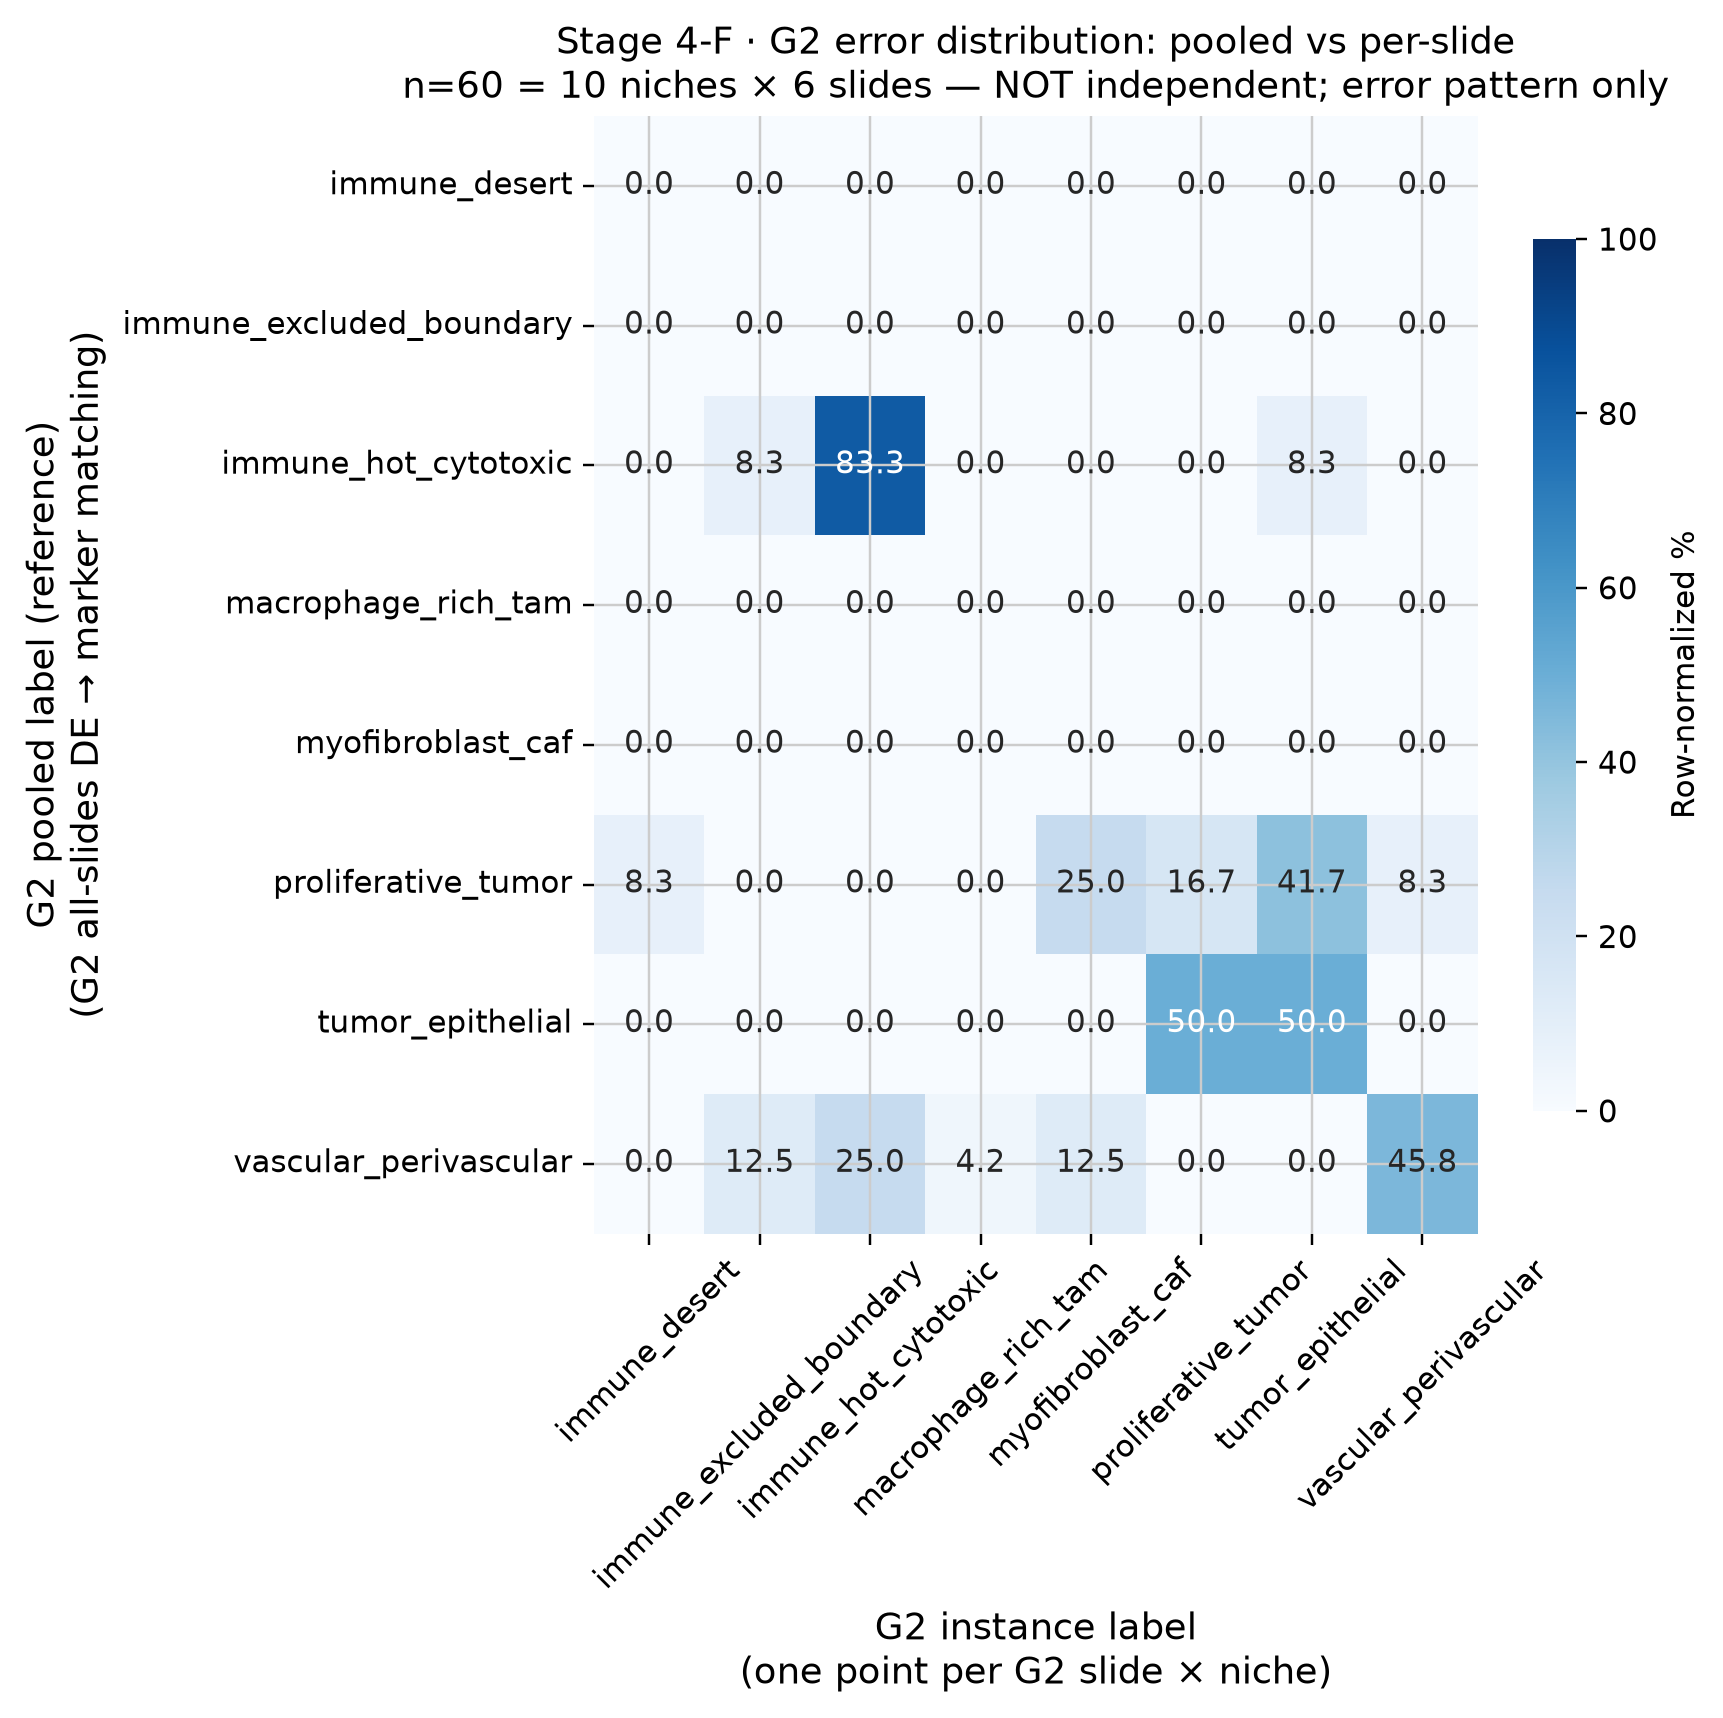

Instance CM: 29/60 on diagonal
Saved: /workspace/spie2027/outputs/v1/nn/g2_instance_label_cm.png


In [ ]:
# Stage 4-F: G2 per-slide instance labeling (mirrors Stage 2-E for G2).
# Each (sample_id, niche_group) in G2 gets its own DE + empirical-p label,
# then compared against G2's pooled empirical-p label (the Stage 4-E ground truth).
print("Stage 4-F — G2 per-slide instance analysis...")

g2_instance_labels = _run_per_instance_labeling(
    adata_g2, G2_STEMS, g2_niche_cols, marker_catalog, "G2", MIN_CELLS_PER_INSTANCE
)
for col in ["niche_label"]:
    g2_instance_labels[col] = harmonize_label_series(g2_instance_labels[col].fillna(""))

valid_g2 = g2_instance_labels[~g2_instance_labels["niche_label"].isin(
    ["skipped_too_few_cells", "no_de_genes", ""]
)]
print(f"  G2 instances with labels: {len(valid_g2)}/{len(g2_instance_labels)}")

# ── (A) Intra-G2: do G2's 6 slides agree per niche? ──────────────────────────
print("\n" + "="*70)
print("(A) Intra-G2 consistency: do G2 slides agree on label per niche?")
print("="*70)
intra_g2 = []
for niche_col, grp in valid_g2.groupby("niche_group"):
    modal   = grp["niche_label"].mode().iloc[0] if not grp.empty else "—"
    n_agree = int((grp["niche_label"] == modal).sum())
    intra_g2.append({"niche_group": niche_col, "modal_label": modal,
                     "n_instances": len(grp), "n_agree": n_agree,
                     "labels": ", ".join(grp["niche_label"].tolist())})
intra_g2_df = pd.DataFrame(intra_g2)
print(intra_g2_df[["niche_group", "modal_label", "n_instances", "n_agree", "labels"]].to_string(index=False))
n_fully = int((intra_g2_df["n_agree"] == intra_g2_df["n_instances"]).sum())
print(f"\nNiches where ALL G2 slides agreed: {n_fully}/{len(intra_g2_df)}")

# ── (B) Instance CM: G2 pooled label vs G2 per-slide ─────────────────────────
g2_pooled_map    = dict(zip(g2_niche_labels["niche_group"], g2_niche_labels["niche_label"]))
inst_cm_rows_g2  = []
for _, row in valid_g2.iterrows():
    ref = harmonize_label_series(pd.Series([g2_pooled_map.get(row["niche_group"], "")])).iloc[0]
    if not ref:
        continue
    inst_cm_rows_g2.append({"ref_label": ref, "inst_label": row["niche_label"],
                              "niche_group": row["niche_group"]})
inst_cm_g2_df = pd.DataFrame(inst_cm_rows_g2)

if len(inst_cm_g2_df) >= 2:
    # Use only ref_labels (pooled G2 labels) as row labels so every row sums to 100%.
    # Instance labels that appear only in predictions but not in the reference would
    # produce zero-sum rows if included.
    inst_labels_g2 = sorted(set(inst_cm_g2_df["ref_label"]))
    cm_inst_g2     = confusion_matrix(inst_cm_g2_df["ref_label"], inst_cm_g2_df["inst_label"],
                                      labels=inst_labels_g2)
    n_corr_g2  = int(np.diag(cm_inst_g2).sum())
    n_total_g2 = int(cm_inst_g2.sum())

    _, _, _ = plot_confusion_matrix_pct(
        cm_inst_g2, inst_labels_g2,
        title=(f"Stage 4-F · G2 error distribution: pooled vs per-slide\n"
               f"n={n_total_g2} = 10 niches × 6 slides — NOT independent; error pattern only"),
        xlabel="G2 instance label\n(one point per G2 slide × niche)",
        ylabel="G2 pooled label (reference)\n(G2 all-slides DE → marker matching)",
        outpath=CFG["nn_dir"] / "g2_instance_label_cm.png",
    )
    print(f"Instance CM: {n_corr_g2}/{n_total_g2} on diagonal")
    print("Saved:", CFG["nn_dir"] / "g2_instance_label_cm.png")


intra_g2_df.to_csv(CFG["nn_dir"] / "g2_instance_label_consistency.csv", index=False)
inst_cm_g2_df.to_csv(CFG["nn_dir"] / "g2_instance_cm_input.csv", index=False)

---

## Stage 5 · Discussion and Conclusion

### What was validated

| Claim | Evidence |
|-------|----------|
| Niche IDs encode biology consistently within a cohort | Stage 2: G1A vs G1B independent label agreement (CM) |
| H&E neighbor composition transfers biology across cohorts | Stage 4: G1-trained NN on G2, validated by independent G2 empirical-p labels |
| Xenium is not required at inference time | Stage 4: predictions use only H&E features |

### Labeling approach

All niche labeling (G1A, G1B, G2) uses the same deterministic pipeline:
1. **Wilcoxon DE** — per niche (in-niche vs rest), strict thresholds (p < 0.001, logFC > 0.5)
2. **Hypergeometric test** — overlap between DE genes and marker catalog (`nichemarkers-v1.csv`)
3. **FDR correction** (Benjamini-Hochberg) — winner = label with minimum FDR-corrected p-value

No GOEA, no LLM. Labels are fully reproducible and parameter-controlled.

### Interpretation

- **High G1A/G1B agreement** (Stage 2) confirms that H&E-defined clusters are
  biologically coherent: the same visual microenvironment → consistent gene expression program.
  This is the foundation that makes label transfer meaningful.

- **Cross-cohort NN accuracy** (Stage 4) measures whether H&E neighbor composition features
  (no Xenium required) can predict the same biological label that independent gene expression
  evidence assigns to G2 niches.

- **Unseen labels** (G2 niche types not represented in G1 training) reflect biology not
  covered by G1's patient cohort. Enlarging G1 would extend coverage.

### Outputs

```
outputs/v1/
  g1a_markers/    G1A_de_all.csv, G1A_marker_labels.csv, niche_labels.csv
  g1b_markers/    (same structure — independent G1B derivation)
  g2_markers/     (same structure — independent G2 derivation)
  nn/             g1_vectors.csv, g2_vectors.csv, niche_mlp.pt, scaler.pkl, label_encoder.pkl
                  g1ab_label_consistency.csv, g1ab_label_consistency_cm.png
                  g1ab_instance_label_consistency.csv, g1ab_instance_label_cm.png
                  g1a_g2_label_consistency.csv
                  g2_predictions.csv, g2_confusion_matrix.csv
                  g2_roc_auc.csv, g2_roc_curves.png, g2_eval_coverage.csv
```


## Stage 6 · Limitations and Reviewer FAQ

### 6-A: Study Limitations

1. **Cohort size.** The 12-portion design (P1–P12) supports independent-group validation, but uncertainty is higher for low-frequency niche classes.

2. **Label dependency.** Niche naming depends on DE filtering thresholds and the marker catalog. Threshold changes can shift label assignments — threshold sensitivity should be reported in supplementary analysis.

3. **Marker panel breadth.** Only 280 Xenium genes are available. Gene symbols absent from the catalog cannot contribute to labeling, limiting sensitivity for rare cell states.

4. **Class imbalance.** Rare niches have fewer cells per DE test and may produce noisier marker sets, leading to lower labeling confidence.

5. **Domain shift.** Differences in tissue preparation, staining, or capture efficiency between cohorts can reduce cross-group transfer performance even when biology is shared.

6. **Instance sample size.** The niche-level comparisons (n = 10 niches per group) are small. Per-slide instance analyses (Stages 2-E and 4-E) show error distributions but are not statistically independent.

---

### 6-B: Reviewer FAQ

**Q1. Why use marker-based labeling instead of manual naming?**  
A1. The hypergeometric test against a curated marker catalog is deterministic and reproducible. Manual naming introduces annotation subjectivity; this pipeline produces the same labels for the same data regardless of who runs it.

**Q2. How do you control label leakage in cross-group transfer?**  
A2. Niche discovery is run independently for G1 and G2; G2 labels are derived independently (separate DE run on G2 patients) and used as held-out biological ground truth with no reference to G1 labels.

**Q3. How robust are labels to marker threshold choices?**  
A3. Threshold sensitivity can be profiled by rerunning DE + empirical-p under small parameter perturbations and measuring label stability across runs.

**Q4. What is the key scientific claim?**  
A4. H&E-derived cell-neighbor composition features encode biologically interpretable niche types that are transferable across independently processed patient cohorts — without requiring Xenium at inference time.

---

### 6-C: Optional Supplementary Robustness Checks

- Bootstrap confidence intervals for AUC/F1 and per-class metrics.
- Multi-seed repeats for DGI, clustering, and NN training.
- Sample-wise leave-one-out cross-validation.
- Stability of empirical-p labels under DE threshold perturbation.
- Rare-niche analysis with minimum-cell filtering and uncertainty reporting.
